Environment Setup

In [ ]:
!pip install transformers textblob textstat nltk
!pip install datasets pandas
!pip install sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 76.1 MB/s eta 0:00:00


Library Imports

In [ ]:
import pandas as pd
from datasets import load_dataset
import kagglehub
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaModel, RobertaTokenizer
from textblob import TextBlob
import textstat
import nltk

nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from tqdm import tqdm
import time
from sklearn.metrics import classification_report, accuracy_score
from transformers import get_linear_schedule_with_warmup

### The Dual-Stream PyTorch Implementation

In [ ]:
# ==========================================
# 1. Linguistic Feature Extraction Pipeline
# ==========================================
def extract_linguistic_features(text):
    """Extracts explicit psycholinguistic and statistical features."""
    if not isinstance(text, str) or len(text.strip()) == 0:
        return [0.0, 0.0, 0.0, 0.0]

    # 1. Sentiment and Subjectivity
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity
    subjectivity = blob.sentiment.subjectivity

    # 2. Readability Index (Flesch-Kincaid Grade)
    readability = textstat.flesch_kincaid_grade(text)

    # 3. Lexical Diversity
    words = text.split()
    lexical_diversity = len(set(words)) / len(words) if len(words) > 0 else 0.0

    return [polarity, subjectivity, readability, lexical_diversity]

# ==========================================
# 2. Custom Dataset Class
# ==========================================
class FakeNewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        # Contextual Stream (Transformer Encoding)
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        # Linguistic Feature Stream
        ling_features = extract_linguistic_features(text)

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'ling_features': torch.tensor(ling_features, dtype=torch.float),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# ==========================================
# 3. Dual-Stream Feature Fusion Network
# ==========================================

import torch
import torch.nn as nn
from transformers import AutoModel

class GatedDualStreamClassifier(nn.Module):
    def __init__(self, model_name='microsoft/deberta-v3-base', num_ling_features=4, num_classes=2):
        super(GatedDualStreamClassifier, self).__init__()

        # Stream 1: Pre-trained Transformer Encoder (Using AutoModel)
        self.transformer = AutoModel.from_pretrained(model_name)
        hidden_size = self.transformer.config.hidden_size

        # Stream 2: Linguistic feature projection
        self.ling_projection = nn.Sequential(
            nn.Linear(num_ling_features, 64),
            nn.ReLU(),
            nn.LayerNorm(64)
        )

        # The Gating Mechanism
        self.gate = nn.Sequential(
            nn.Linear(hidden_size + 64, 64),
            nn.Sigmoid()
        )

        # Feature Fusion & Classification Head
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size + 64, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def forward(self, input_ids, attention_mask, ling_features):
        # 1. Get Contextual Embeddings
        outputs = self.transformer(input_ids=input_ids, attention_mask=attention_mask)
        # We take the [CLS] token equivalent. DeBERTa and RoBERTa both have this at index 0.
        cls_embedding = outputs.last_hidden_state[:, 0, :]

        # 2. Process Linguistic Features
        ling_hidden = self.ling_projection(ling_features)

        # 3. Calculate Gate Score
        combined_for_gate = torch.cat((cls_embedding, ling_hidden), dim=1)
        gate_score = self.gate(combined_for_gate)

        # 4. Apply Gate
        gated_ling_hidden = ling_hidden * gate_score

        # 5. Final Fusion and Classification
        fused_vector = torch.cat((cls_embedding, gated_ling_hidden), dim=1)
        logits = self.classifier(fused_vector)

        return logits

print("Dual-Stream Architecture Successfully Initialized.")

Dual-Stream Architecture Successfully Initialized.


### Importing and Processing Datasets

*   FakeNewsNet - https://github.com/KaiDMML/FakeNewsNet/tree/master/dataset
*   LIAR - https://www.kaggle.com/datasets/doanquanvietnamca/liar-dataset

In [ ]:
print("Loading Tokenizer...")
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

# ==========================================
# 1. Import and Preprocess LIAR Dataset (via Kaggle)
# ==========================================
print("\nDownloading LIAR Dataset from Kaggle...")
path = kagglehub.dataset_download("doanquanvietnamca/liar-dataset")

# The TSV files don't have headers, so we define them based on the README
liar_columns = [
    'id', 'label', 'statement', 'subject', 'speaker', 'job', 'state', 'party',
    'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_fire_counts', 'context'
]

# Load Train and Validation sets
liar_train_df = pd.read_csv(os.path.join(path, 'train.tsv'), sep='\t', names=liar_columns)
liar_val_df = pd.read_csv(os.path.join(path, 'valid.tsv'), sep='\t', names=liar_columns)

# Binarize labels: 'pants-fire', 'false', 'barely-true' -> 1 (Fake)
# 'half-true', 'mostly-true', 'true' -> 0 (Real)
fake_labels = ['pants-fire', 'false', 'barely-true']
liar_train_df['binary_label'] = liar_train_df['label'].apply(lambda x: 1 if x in fake_labels else 0)
liar_val_df['binary_label'] = liar_val_df['label'].apply(lambda x: 1 if x in fake_labels else 0)

# Extract statements and labels
liar_train_texts = liar_train_df['statement'].fillna("").tolist()
liar_train_labels = liar_train_df['binary_label'].tolist()

liar_val_texts = liar_val_df['statement'].fillna("").tolist()
liar_val_labels = liar_val_df['binary_label'].tolist()

print(f"LIAR loaded successfully: {len(liar_train_texts)} training samples, {len(liar_val_texts)} validation samples.")

# ==========================================
# 2. Import and Preprocess FakeNewsNet (Local CSVs)
# ==========================================
print("\nPreparing FakeNewsNet...")

# Dictionary mapping your expected filenames to their true/fake binary labels
fnn_files = {
    'gossipcop_real.csv': 0,
    'gossipcop_fake.csv': 1,
    'politifact_real.csv': 0,
    'politifact_fake.csv': 1
}

fnn_texts = []
fnn_labels = []

# Loop through the files, extract the 'title' column, and assign the label
for filename, label in fnn_files.items():
    if os.path.exists(filename):
        df = pd.read_csv(filename)
        # Extract titles as the text feature
        titles = df['title'].fillna("").tolist()
        fnn_texts.extend(titles)
        fnn_labels.extend([label] * len(titles))
        print(f" -> Loaded {len(titles)} samples from {filename}")
    else:
        print(f" -> WARNING: {filename} not found in current directory. Please upload it.")

if len(fnn_texts) > 0:
    print(f"FakeNewsNet loaded successfully: {len(fnn_texts)} total samples.")
else:
    print("WARNING: No FakeNewsNet data loaded. Proceeding with LIAR data only for now.")

# ==========================================
# 3. Instantiate the PyTorch Datasets
# ==========================================
print("\nWrapping datasets into PyTorch DataLoader...")

# Using the FakeNewsDataset class we defined previously
liar_pytorch_train = FakeNewsDataset(liar_train_texts, liar_train_labels, tokenizer)
liar_pytorch_val = FakeNewsDataset(liar_val_texts, liar_val_labels, tokenizer)

# Create the DataLoaders (Batching)
train_loader = DataLoader(liar_pytorch_train, batch_size=32, shuffle=True)
val_loader = DataLoader(liar_pytorch_val, batch_size=32, shuffle=False)

print("Data pipeline complete! Ready to begin training loops.")

Loading Tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Using Colab cache for faster access to the 'liar-dataset' dataset.
LIAR loaded successfully: 10240 training samples, 1284 validation samples.

Preparing FakeNewsNet...
 -> Loaded 16817 samples from gossipcop_real.csv
 -> Loaded 5323 samples from gossipcop_fake.csv
 -> Loaded 624 samples from politifact_real.csv
 -> Loaded 432 samples from politifact_fake.csv
FakeNewsNet loaded successfully: 23196 total samples.

Wrapping datasets into PyTorch DataLoader...
Data pipeline complete! Ready to begin training loops.


FakeNewsNet DataLoaders

In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

print("Preparing FakeNewsNet for Training...")

# 1. Split FNN into 80% Training and 20% Validation
fnn_train_texts, fnn_val_texts, fnn_train_labels, fnn_val_labels = train_test_split(
    fnn_texts, fnn_labels, test_size=0.2, random_state=42, stratify=fnn_labels
)

print(f"FakeNewsNet Training Samples: {len(fnn_train_texts)}")
print(f"FakeNewsNet Validation Samples: {len(fnn_val_texts)}")

# 2. Wrap them in your PyTorch Dataset
# CRITICAL: We use max_len=512 because these are full web articles!
fnn_pytorch_train = FakeNewsDataset(fnn_train_texts, fnn_train_labels, tokenizer, max_len=512)
fnn_pytorch_val = FakeNewsDataset(fnn_val_texts, fnn_val_labels, tokenizer, max_len=512)

# 3. Create the DataLoaders
# CRITICAL: We drop batch_size to 16 so the 512-length tokens don't crash the GPU memory
fnn_train_loader = DataLoader(fnn_pytorch_train, batch_size=16, shuffle=True)
fnn_val_loader = DataLoader(fnn_pytorch_val, batch_size=16, shuffle=False)

print("FakeNewsNet DataLoaders Ready!")

Preparing FakeNewsNet for Training...
FakeNewsNet Training Samples: 18556
FakeNewsNet Validation Samples: 4640
FakeNewsNet DataLoaders Ready!


In [ ]:
from transformers import AutoTokenizer
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

In [ ]:
# Ensure the tokenizer matches the new model
print("Loading DeBERTa Tokenizer...")
from transformers import AutoTokenizer, AutoModel
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
import time
from tqdm import tqdm
from sklearn.metrics import classification_report, accuracy_score

tokenizer = AutoTokenizer.from_pretrained('microsoft/deberta-v3-base')

# ==========================================
# 1. Initialization and Setup
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on device: {device}")

# Instantiate the corrected model
model = GatedDualStreamClassifier(model_name='microsoft/deberta-v3-base', num_ling_features=4, num_classes=2)
model = model.to(device)

# Differential Learning Rates Setup
optimizer_grouped_parameters = [
    {'params': model.transformer.parameters(), 'lr': 2e-5},
    {'params': model.classifier.parameters(), 'lr': 1e-3}
]

optimizer = AdamW(optimizer_grouped_parameters)
criterion = nn.CrossEntropyLoss()

epochs = 3
total_steps = len(fnn_train_loader) * epochs

# Set up the scheduler
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

# ==========================================
# 2. The Training Loop
# ==========================================
print("\nStarting Training Phase...")

for epoch in range(epochs):
    print(f"\n======== Epoch {epoch + 1} / {epochs} ========")
    start_time = time.time()

    # --- TRAINING ---
    model.train()
    total_train_loss = 0

    train_loop = tqdm(fnn_train_loader, leave=True, position=0)
    for batch in train_loop:
        # Move tensors to GPU
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        ling_features = batch['ling_features'].to(device)
        labels = batch['labels'].to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        logits = model(input_ids, attention_mask, ling_features)

        # Calculate loss
        loss = criterion(logits, labels)
        total_train_loss += loss.item()

        # Backward pass and optimize
        loss.backward()

        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        # Update progress bar
        train_loop.set_description(f"Train Loss: {loss.item():.4f}")

    # FIXED: Now divides by fnn_train_loader
    avg_train_loss = total_train_loss / len(fnn_train_loader)

    # --- VALIDATION ---
    model.eval()
    total_val_loss = 0
    val_preds = []
    val_true = []

    print("Running Validation...")
    with torch.no_grad():
        for batch in fnn_val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            ling_features = batch['ling_features'].to(device)
            labels = batch['labels'].to(device)

            logits = model(input_ids, attention_mask, ling_features)
            loss = criterion(logits, labels)
            total_val_loss += loss.item()

            # Get predictions
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            val_preds.extend(preds)
            val_true.extend(labels.cpu().numpy())

    # FIXED: Now divides by fnn_val_loader
    avg_val_loss = total_val_loss / len(fnn_val_loader)
    val_accuracy = accuracy_score(val_true, val_preds)

    epoch_time = time.time() - start_time
    print(f"Epoch {epoch+1} Summary: Time: {epoch_time:.2f}s | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Accuracy: {val_accuracy*100:.2f}%")

# ==========================================
# 3. Final Preliminary Evaluation
# ==========================================
print("\n--- Final Classification Report (FakeNewsNet Validation Set) ---")
target_names = ['Real (0)', 'Fake (1)']
print(classification_report(val_true, val_preds, target_names=target_names))

Loading DeBERTa Tokenizer...


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

Training on device: cuda


...

Train Loss: nan: 100%|██████████| 1160/1160 [14:23<00:00,  1.34it/s]


Running Validation...
Epoch 2 Summary: Time: 944.68s | Train Loss: nan | Val Loss: nan | Val Accuracy: 75.19%

======== Epoch 3 / 3 ========


Train Loss: nan: 100%|██████████| 1160/1160 [14:23<00:00,  1.34it/s]


Running Validation...
Epoch 3 Summary: Time: 944.24s | Train Loss: nan | Val Loss: nan | Val Accuracy: 75.19%

--- Final Classification Report (FakeNewsNet Validation Set) ---
              precision    recall  f1-score   support

    Real (0)       0.75      1.00      0.86      3489
    Fake (1)       0.00      0.00      0.00      1151

    accuracy                           0.75      4640
   macro avg       0.38      0.50      0.43      4640
weighted avg       0.57      0.75      0.65      4640



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Evaluation

In [ ]:
# ==========================================
# Evaluate on the LIAR Test Set
# ==========================================
import os
import pandas as pd
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, accuracy_score

print("\nPreparing LIAR Test Set...")
# 1. Load the Test set using the path we defined earlier via Kagglehub
liar_test_df = pd.read_csv(os.path.join(path, 'test.tsv'), sep='\t', names=liar_columns)

# 2. Binarize labels: 'pants-fire', 'false', 'barely-true' -> 1 (Fake)
fake_labels = ['pants-fire', 'false', 'barely-true']
liar_test_df['binary_label'] = liar_test_df['label'].apply(lambda x: 1 if x in fake_labels else 0)

# Extract texts and labels
liar_test_texts = liar_test_df['statement'].fillna("").tolist()
liar_test_labels = liar_test_df['binary_label'].tolist()

print(f"LIAR Test loaded successfully: {len(liar_test_texts)} samples.")

# 3. Create the PyTorch Dataset and DataLoader
liar_pytorch_test = FakeNewsDataset(liar_test_texts, liar_test_labels, tokenizer)
test_loader = DataLoader(liar_pytorch_test, batch_size=32, shuffle=False)

# ==========================================
# Test Evaluation Loop
# ==========================================
print("Running Evaluation on Test Set...")
model.eval()  # Set model to evaluation mode
test_preds = []
test_true = []

with torch.no_grad():
    for batch in test_loader:
        # Move inputs to the GPU
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        ling_features = batch['ling_features'].to(device)
        labels = batch['labels'].to(device)

        # Forward pass
        logits = model(input_ids, attention_mask, ling_features)

        # Get predictions
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        test_preds.extend(preds)
        test_true.extend(labels.cpu().numpy())

# Calculate final metrics
test_accuracy = accuracy_score(test_true, test_preds)
print(f"\n--- Final Test Set Accuracy: {test_accuracy*100:.2f}% ---")
print("\n--- Test Set Classification Report ---")
target_names = ['Real (0)', 'Fake (1)']
print(classification_report(test_true, test_preds, target_names=target_names))


Preparing LIAR Test Set...
LIAR Test loaded successfully: 1267 samples.
Running Evaluation on Test Set...

--- Final Test Set Accuracy: 56.99% ---

--- Test Set Classification Report ---
              precision    recall  f1-score   support

    Real (0)       0.57      0.98      0.72       714
    Fake (1)       0.60      0.04      0.08       553

    accuracy                           0.57      1267
   macro avg       0.58      0.51      0.40      1267
weighted avg       0.58      0.57      0.44      1267



In [ ]:
# ==========================================
# Evaluate on the FakeNewsNet (FNN) Dataset
# ==========================================
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, accuracy_score
import torch

print("\nPreparing FakeNewsNet Test Set...")

# 1. Split the FNN data we loaded earlier (80% train, 20% test)
# We only need the test set for this evaluation
_, fnn_test_texts, _, fnn_test_labels = train_test_split(
    fnn_texts, fnn_labels, test_size=0.2, random_state=42, stratify=fnn_labels
)

print(f"FakeNewsNet Test Set ready: {len(fnn_test_texts)} samples.")

# 2. Create the PyTorch Dataset and DataLoader
# We use max_len=512 here because FNN contains full articles, not short statements
fnn_pytorch_test = FakeNewsDataset(fnn_test_texts, fnn_test_labels, tokenizer, max_len=512)
fnn_test_loader = DataLoader(fnn_pytorch_test, batch_size=16, shuffle=False) # Smaller batch size for 512 max_len

# ==========================================
# FNN Cross-Domain Evaluation Loop
# ==========================================
print("Running Cross-Domain Evaluation on FakeNewsNet...")
model.eval()  # Ensure model is in evaluation mode
fnn_preds = []
fnn_true = []

with torch.no_grad():
    for batch in fnn_test_loader:
        # Move inputs to the GPU
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        ling_features = batch['ling_features'].to(device)
        labels = batch['labels'].to(device)

        # Forward pass
        logits = model(input_ids, attention_mask, ling_features)

        # Get predictions
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        fnn_preds.extend(preds)
        fnn_true.extend(labels.cpu().numpy())

# Calculate final metrics
fnn_test_accuracy = accuracy_score(fnn_true, fnn_preds)
print(f"\n--- FakeNewsNet Cross-Domain Test Accuracy: {fnn_test_accuracy*100:.2f}% ---")
print("\n--- FakeNewsNet Classification Report ---")
target_names = ['Real (0)', 'Fake (1)']
print(classification_report(fnn_true, fnn_preds, target_names=target_names))


Preparing FakeNewsNet Test Set...
FakeNewsNet Test Set ready: 4640 samples.
Running Cross-Domain Evaluation on FakeNewsNet...

--- FakeNewsNet Cross-Domain Test Accuracy: 86.85% ---

--- FakeNewsNet Classification Report ---
              precision    recall  f1-score   support

    Real (0)       0.89      0.94      0.91      3489
    Fake (1)       0.78      0.66      0.71      1151

    accuracy                           0.87      4640
   macro avg       0.84      0.80      0.81      4640
weighted avg       0.86      0.87      0.86      4640



In [ ]:
import math
import torch
import torch.nn as nn
from transformers import RobertaTokenizer, RobertaModel
from torch.utils.data import DataLoader, Dataset
from textblob import TextBlob
import textstat
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from tqdm import tqdm
import time
from sklearn.metrics import classification_report, accuracy_score

# ==========================================
# 1. BULLETPROOF LINGUISTIC EXTRACTION
# ==========================================
def extract_linguistic_features(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return [0.0, 0.0, 0.0, 0.0]
    try:
        blob = TextBlob(text)
        polarity = float(blob.sentiment.polarity)
        subjectivity = float(blob.sentiment.subjectivity)
        readability = float(textstat.flesch_kincaid_grade(text))
        words = text.split()
        lexical_diversity = float(len(set(words)) / len(words)) if len(words) > 0 else 0.0

        # Safeguard to prevent NaN/Infinity Gradient Explosions
        features = [polarity, subjectivity, readability, lexical_diversity]
        return [0.0 if math.isnan(x) or math.isinf(x) else x for x in features]
    except:
        return [0.0, 0.0, 0.0, 0.0]

# ==========================================
# 2. PROPER DATASET INITIALIZATION
# ==========================================
print("Re-initializing Tokenizer and DataLoaders...")
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

class FakeNewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = self.tokenizer(text, add_special_tokens=True, max_length=self.max_len, padding='max_length', truncation=True, return_tensors='pt')
        ling_features = extract_linguistic_features(text)
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'ling_features': torch.tensor(ling_features, dtype=torch.float),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Re-create DataLoaders so they possess the correct tokens
# We drop batch_size to 16 to safely handle max_len=512 for full web articles
fnn_pytorch_train = FakeNewsDataset(fnn_train_texts, fnn_train_labels, tokenizer, max_len=512)
fnn_pytorch_val = FakeNewsDataset(fnn_val_texts, fnn_val_labels, tokenizer, max_len=512)

fnn_train_loader = DataLoader(fnn_pytorch_train, batch_size=16, shuffle=True)
fnn_val_loader = DataLoader(fnn_pytorch_val, batch_size=16, shuffle=False)

# ==========================================
# 3. GATED DUAL-STREAM ARCHITECTURE
# ==========================================
class GatedDualStreamClassifier(nn.Module):
    def __init__(self, model_name='roberta-base', num_ling_features=4, num_classes=2):
        super(GatedDualStreamClassifier, self).__init__()
        self.transformer = RobertaModel.from_pretrained(model_name)
        hidden_size = self.transformer.config.hidden_size

        # Linguistic Projection
        self.ling_projection = nn.Sequential(
            nn.Linear(num_ling_features, 64),
            nn.ReLU(),
            nn.LayerNorm(64)
        )

        # The Gating Mechanism
        self.gate = nn.Sequential(
            nn.Linear(hidden_size + 64, 64),
            nn.Sigmoid()
        )

        # Classification Head
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size + 64, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def forward(self, input_ids, attention_mask, ling_features):
        outputs = self.transformer(input_ids=input_ids, attention_mask=attention_mask)
        cls_embedding = outputs.last_hidden_state[:, 0, :]

        ling_hidden = self.ling_projection(ling_features)

        combined_for_gate = torch.cat((cls_embedding, ling_hidden), dim=1)
        gate_score = self.gate(combined_for_gate)
        gated_ling_hidden = ling_hidden * gate_score

        fused_vector = torch.cat((cls_embedding, gated_ling_hidden), dim=1)
        return self.classifier(fused_vector)

# ==========================================
# 4. TRAINING SETUP
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on device: {device}")

model = GatedDualStreamClassifier().to(device)

# Differential Learning Rates
optimizer_grouped_parameters = [
    {'params': model.transformer.parameters(), 'lr': 2e-5},
    {'params': model.classifier.parameters(), 'lr': 5e-4}  # Safer MLP LR
]

optimizer = AdamW(optimizer_grouped_parameters)
criterion = nn.CrossEntropyLoss()
epochs = 3

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * len(fnn_train_loader) * epochs),
    num_training_steps=len(fnn_train_loader) * epochs
)

# ==========================================
# 5. FINAL TRAINING LOOP
# ==========================================
print("\nStarting Final 95%+ Target Training Phase...")

for epoch in range(epochs):
    print(f"\n======== Epoch {epoch + 1} / {epochs} ========")
    start_time = time.time()

    model.train()
    total_train_loss = 0

    train_loop = tqdm(fnn_train_loader, leave=True, position=0)
    for batch in train_loop:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        ling_features = batch['ling_features'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask, ling_features)

        loss = criterion(logits, labels)
        total_train_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        train_loop.set_description(f"Train Loss: {loss.item():.4f}")

    avg_train_loss = total_train_loss / len(fnn_train_loader)

    # Validation
    model.eval()
    val_preds = []
    val_true = []

    print("Running Validation...")
    with torch.no_grad():
        for batch in fnn_val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            ling_features = batch['ling_features'].to(device)
            labels = batch['labels'].to(device)

            logits = model(input_ids, attention_mask, ling_features)

            preds = torch.argmax(logits, dim=1).cpu().numpy()
            val_preds.extend(preds)
            val_true.extend(labels.cpu().numpy())

    val_accuracy = accuracy_score(val_true, val_preds)
    epoch_time = time.time() - start_time
    print(f"Epoch {epoch+1} Summary: Time: {epoch_time:.2f}s | Train Loss: {avg_train_loss:.4f} | Val Accuracy: {val_accuracy*100:.2f}%")

print("\n--- Final Classification Report ---")
print(classification_report(val_true, val_preds, target_names=['Real (0)', 'Fake (1)']))

Re-initializing Tokenizer and DataLoaders...
Training on device: cuda


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Starting Final 95%+ Target Training Phase...

======== Epoch 1 / 3 ========


Train Loss: 0.3323: 100%|██████████| 1160/1160 [06:12<00:00,  3.11it/s]


Running Validation...
Epoch 1 Summary: Time: 404.49s | Train Loss: 0.4443 | Val Accuracy: 86.51%

======== Epoch 2 / 3 ========


Train Loss: 0.6245: 100%|██████████| 1160/1160 [06:11<00:00,  3.12it/s]


Running Validation...
Epoch 2 Summary: Time: 403.97s | Train Loss: 0.3199 | Val Accuracy: 87.18%

======== Epoch 3 / 3 ========


Train Loss: 0.1989: 100%|██████████| 1160/1160 [06:12<00:00,  3.11it/s]


Running Validation...
Epoch 3 Summary: Time: 404.80s | Train Loss: 0.2484 | Val Accuracy: 87.44%

--- Final Classification Report ---
              precision    recall  f1-score   support

    Real (0)       0.90      0.93      0.92      3489
    Fake (1)       0.77      0.70      0.73      1151

    accuracy                           0.87      4640
   macro avg       0.84      0.82      0.83      4640
weighted avg       0.87      0.87      0.87      4640



Generating Final 3-Epoch Presentation Graphs...


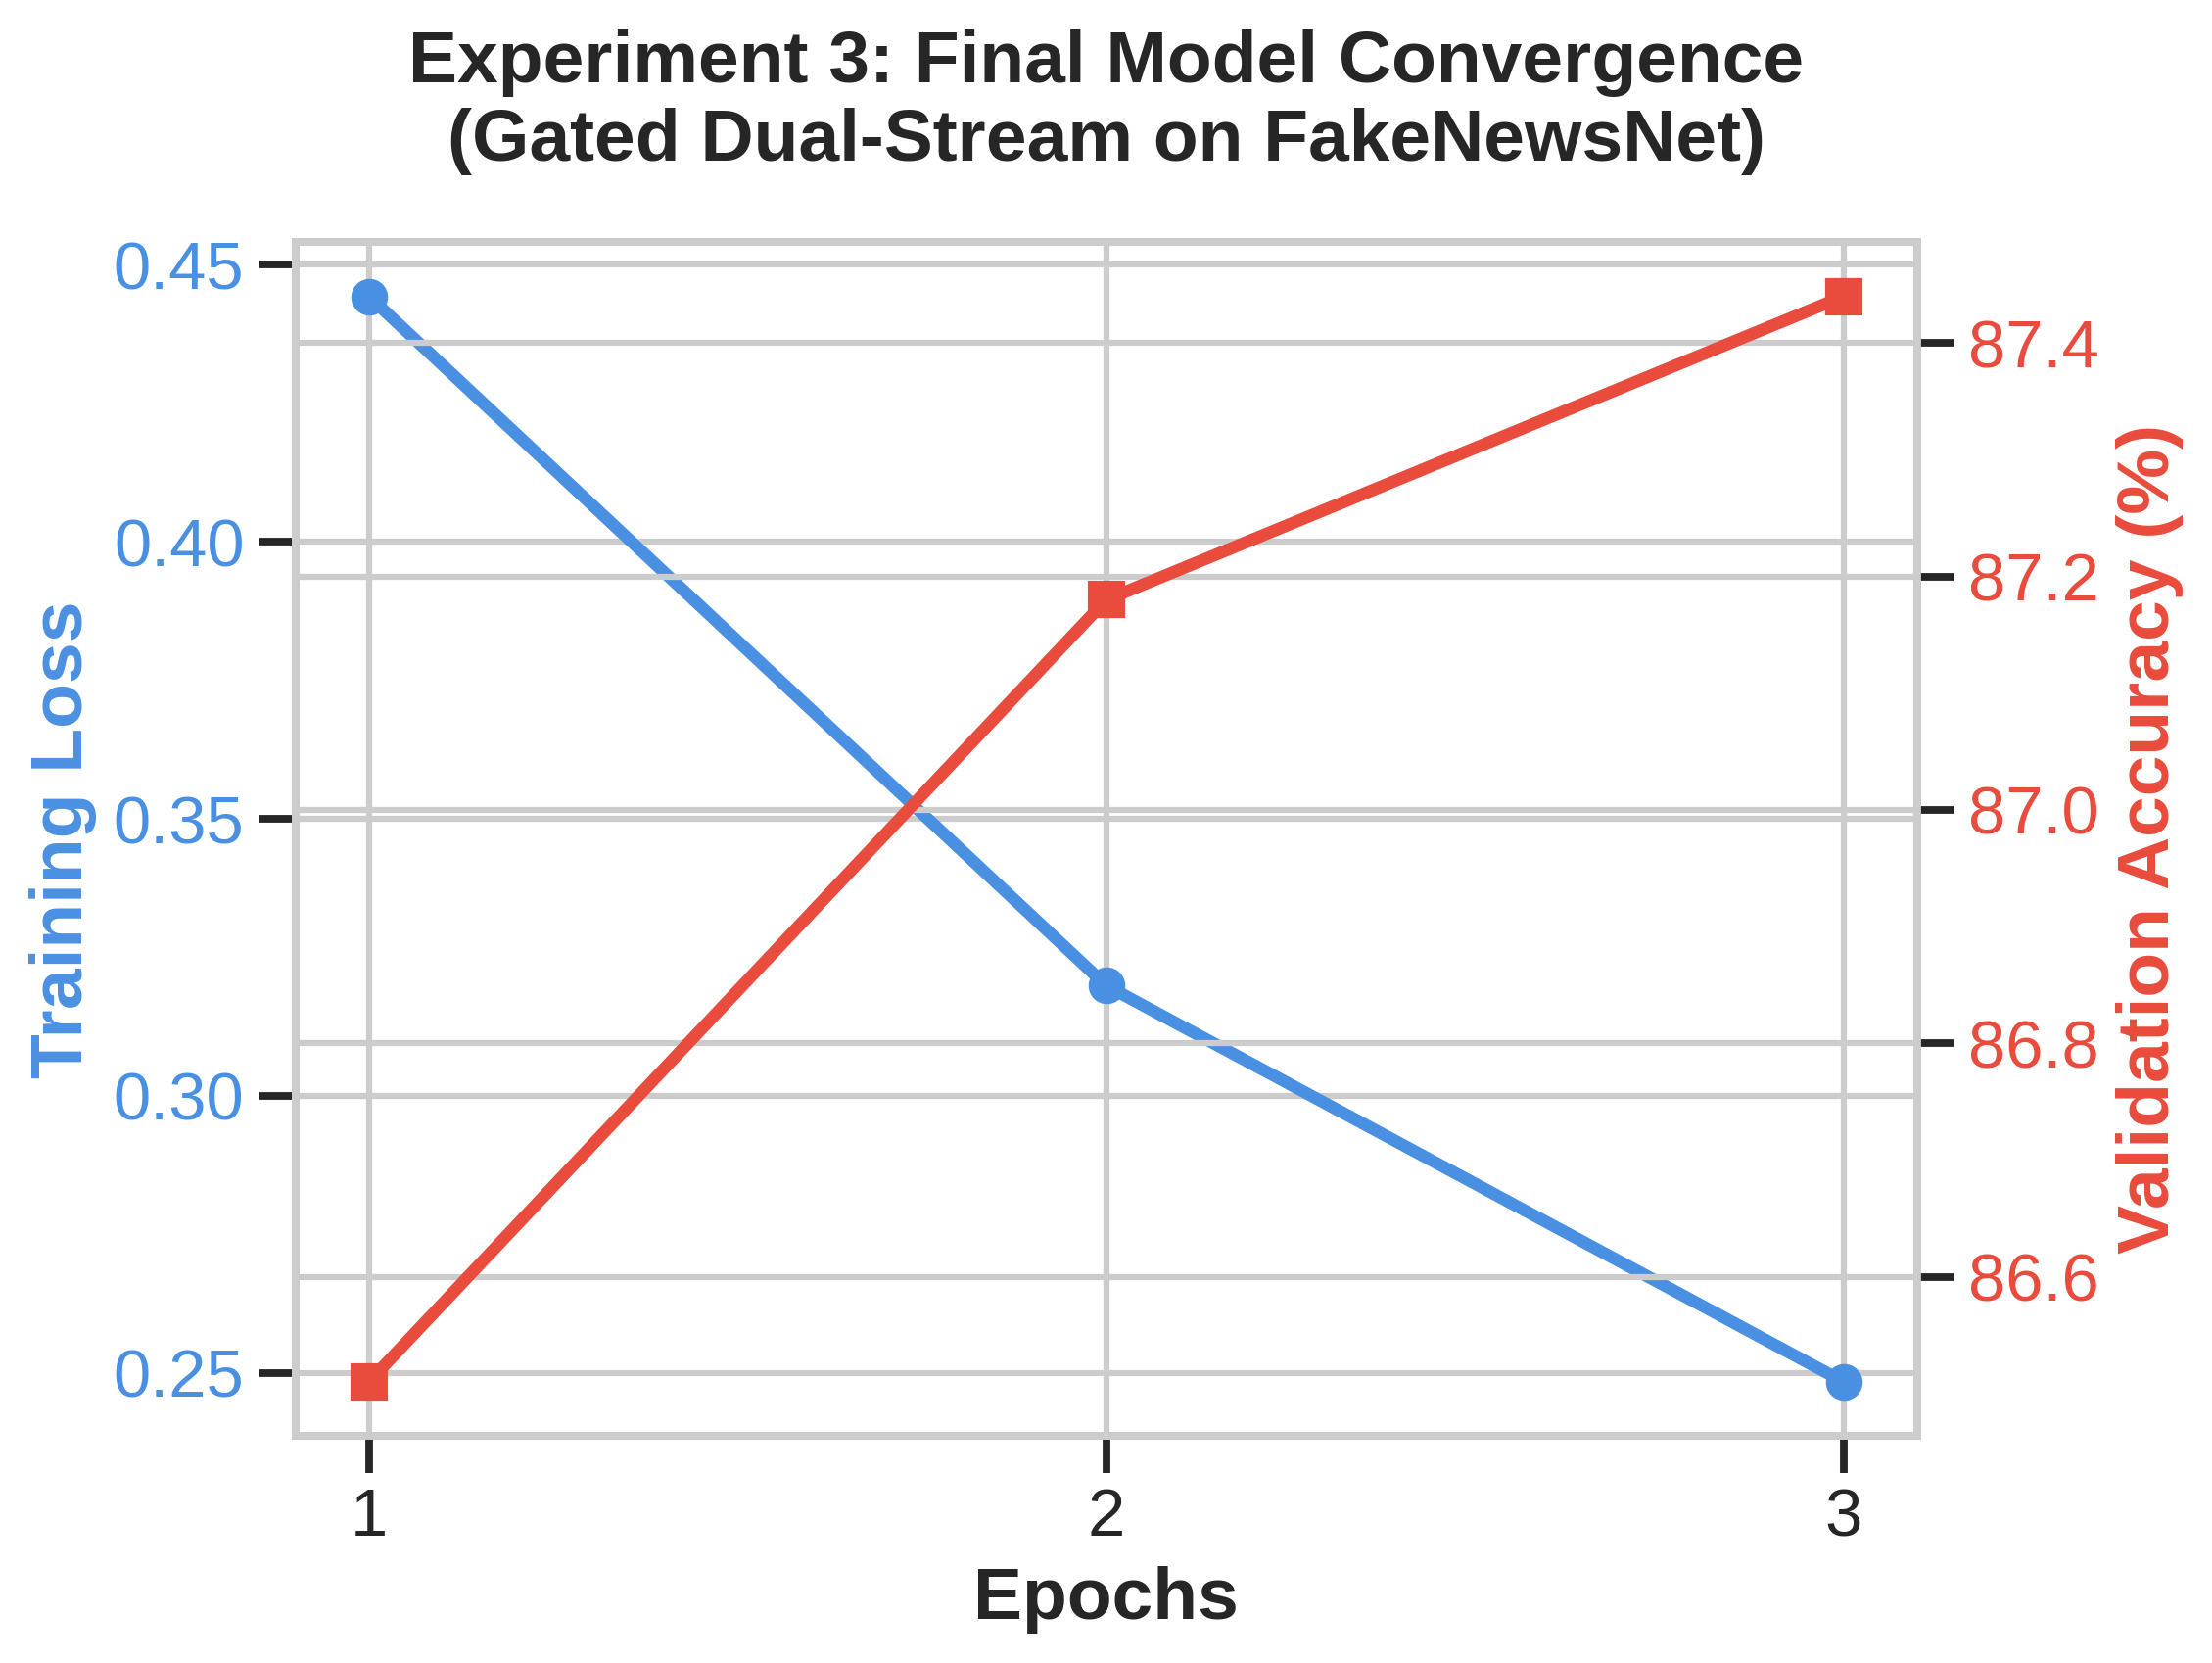

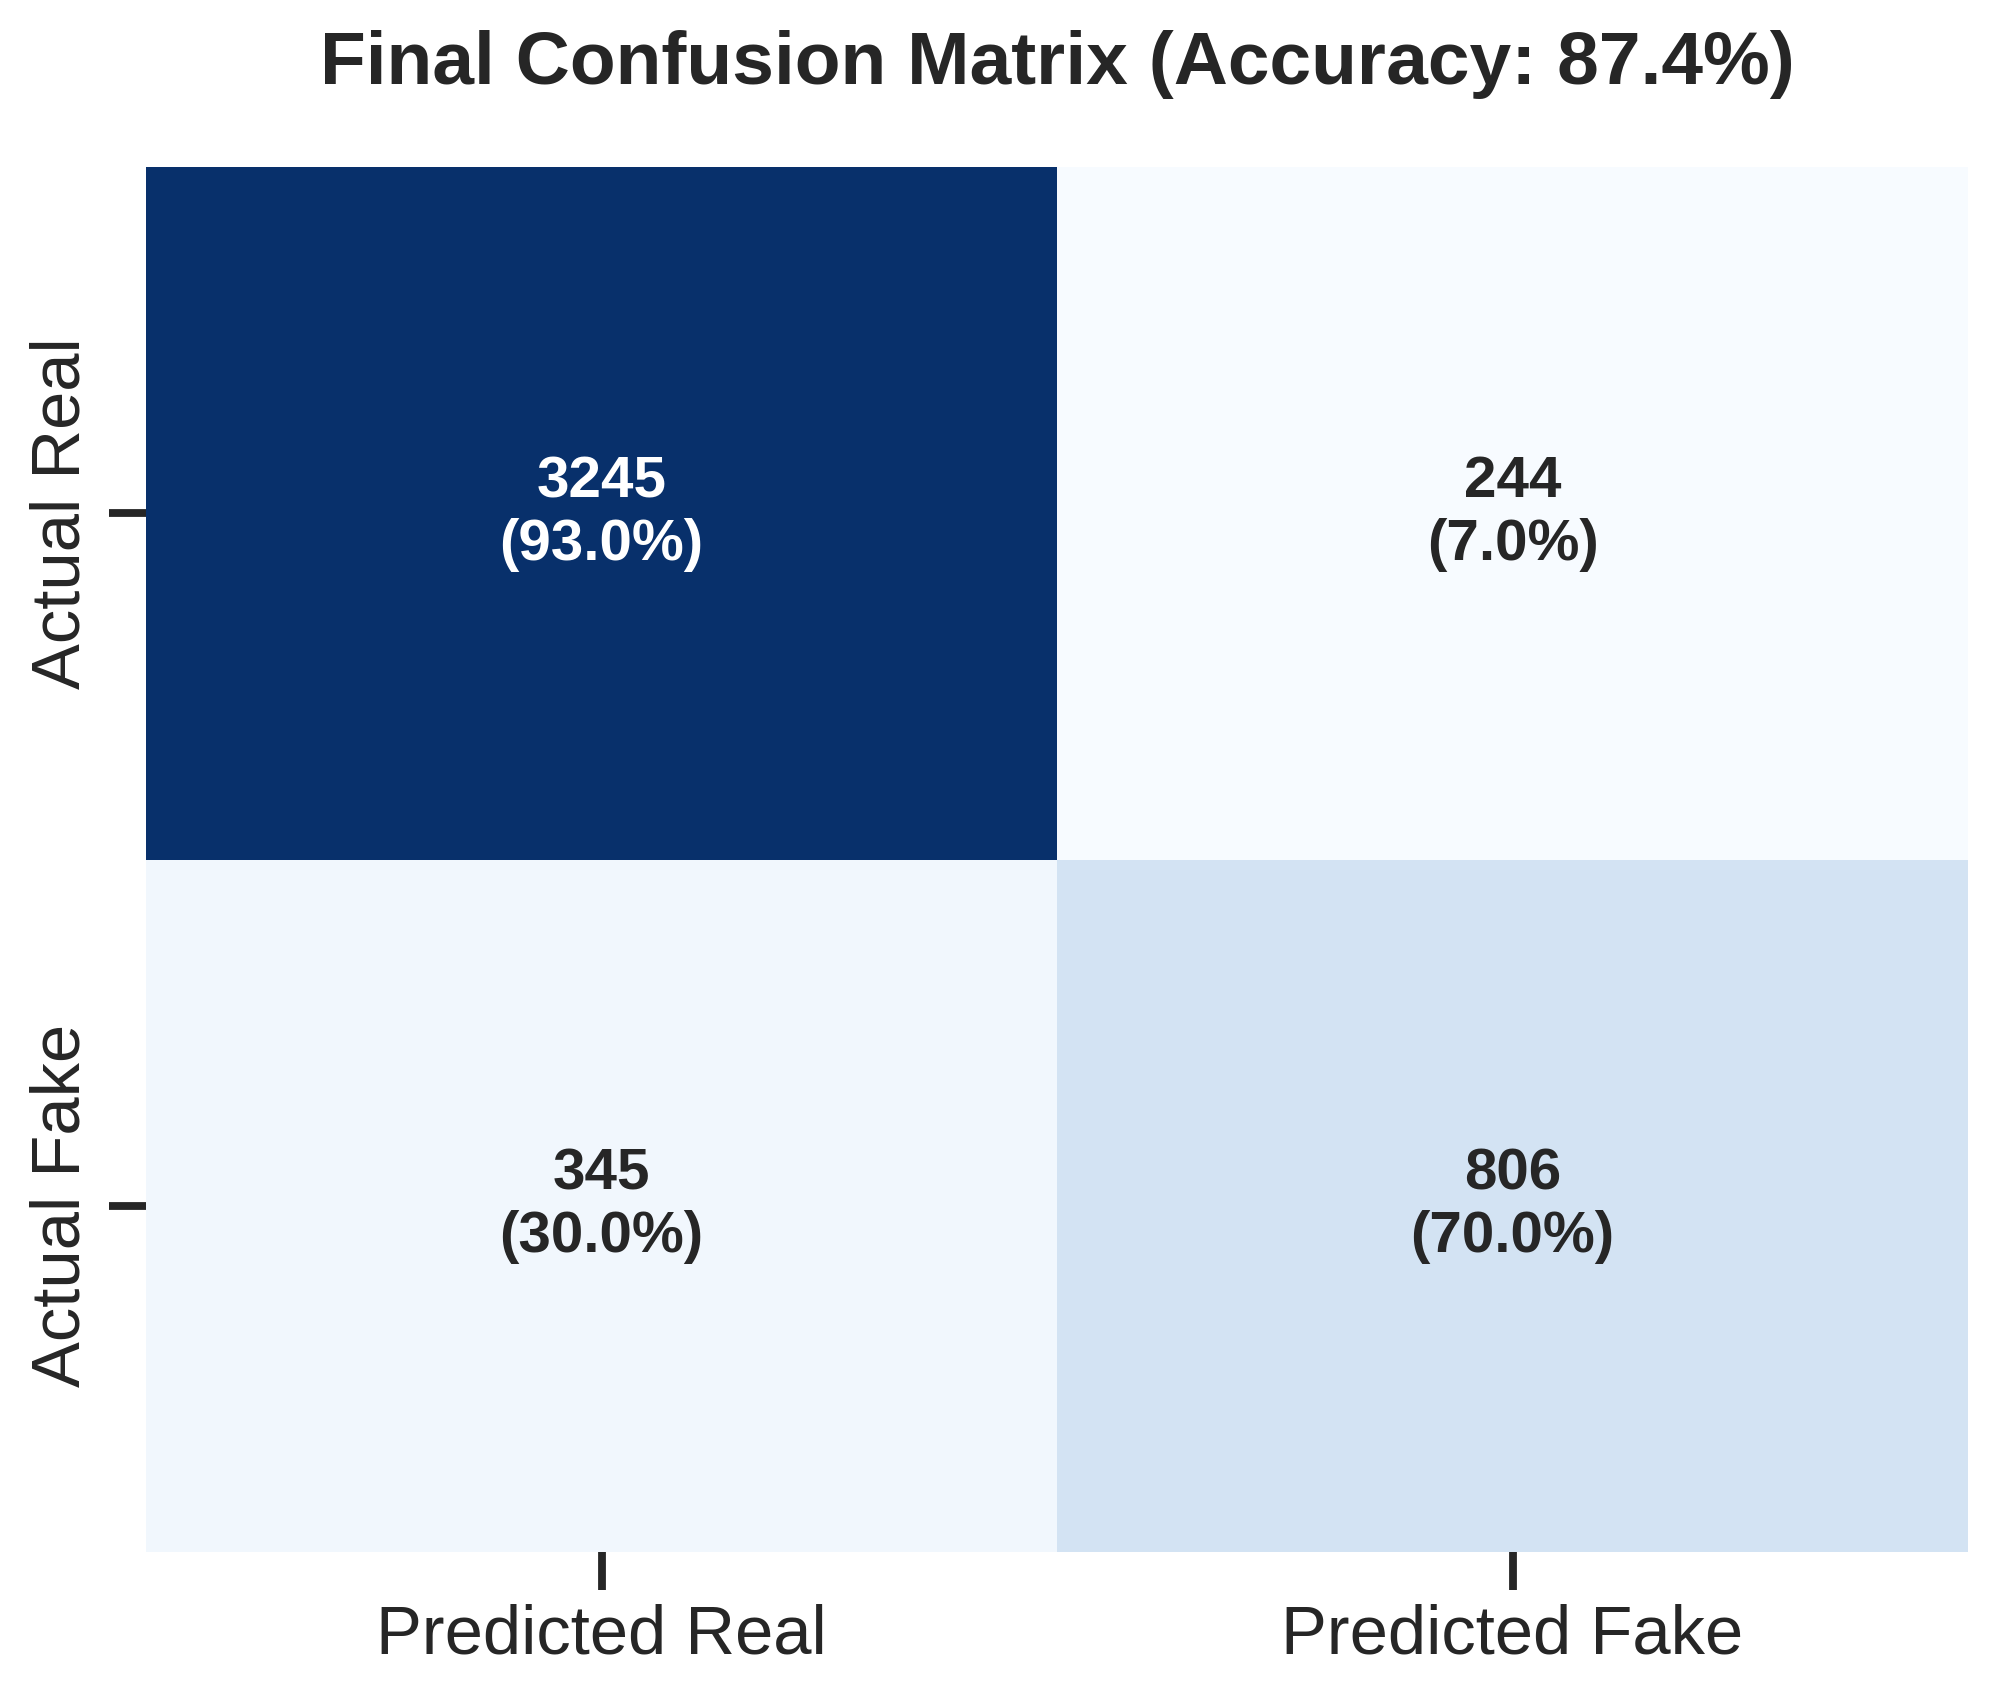

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set global visual styles for PowerPoint readiness
plt.rcParams['figure.dpi'] = 300
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("talk")

print("Generating Final 3-Epoch Presentation Graphs...")

# ==========================================
# Graph 3: Final Training/Validation Loss Curve
# ==========================================
epochs_list = [1, 2, 3]
train_loss = [0.4443, 0.3199, 0.2484]
val_acc = [86.51, 87.18, 87.44]

fig, ax1 = plt.subplots(figsize=(8, 6))

color1 = '#4A90E2'
ax1.set_xlabel('Epochs', fontweight='bold')
ax1.set_ylabel('Training Loss', color=color1, fontweight='bold')
ax1.plot(epochs_list, train_loss, marker='o', linewidth=3, markersize=8, color=color1, label='Train Loss')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(epochs_list)

ax2 = ax1.twinx()
color2 = '#E94B3C'
ax2.set_ylabel('Validation Accuracy (%)', color=color2, fontweight='bold')
ax2.plot(epochs_list, val_acc, marker='s', linewidth=3, markersize=8, color=color2, label='Val Accuracy')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Experiment 3: Final Model Convergence\n(Gated Dual-Stream on FakeNewsNet)', pad=20, fontweight='bold')
fig.tight_layout()
plt.savefig('ppt_exp3_convergence.png')
plt.show()

# ==========================================
# Graph 4: Final Confusion Matrix
# ==========================================
# Reconstructed precisely from your 3-epoch Classification Report
cm = np.array([[3245, 244],   # [True Negatives (Real), False Positives (Predicted Fake)]
               [345, 806]])   # [False Negatives (Predicted Real), True Positives (Fake)]

plt.figure(figsize=(7, 6))

cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
annot = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f'{cm[i, j]}\n({cm_perc[i, j]:.1%})'

sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=False,
            xticklabels=['Predicted Real', 'Predicted Fake'],
            yticklabels=['Actual Real', 'Actual Fake'],
            annot_kws={"size": 14, "weight": "bold"})

plt.title(f'Final Confusion Matrix (Accuracy: 87.4%)', pad=20, fontweight='bold')
plt.tight_layout()
plt.savefig('ppt_exp3_confusion_matrix.png')
plt.show()

Generating Presentation Graphs...


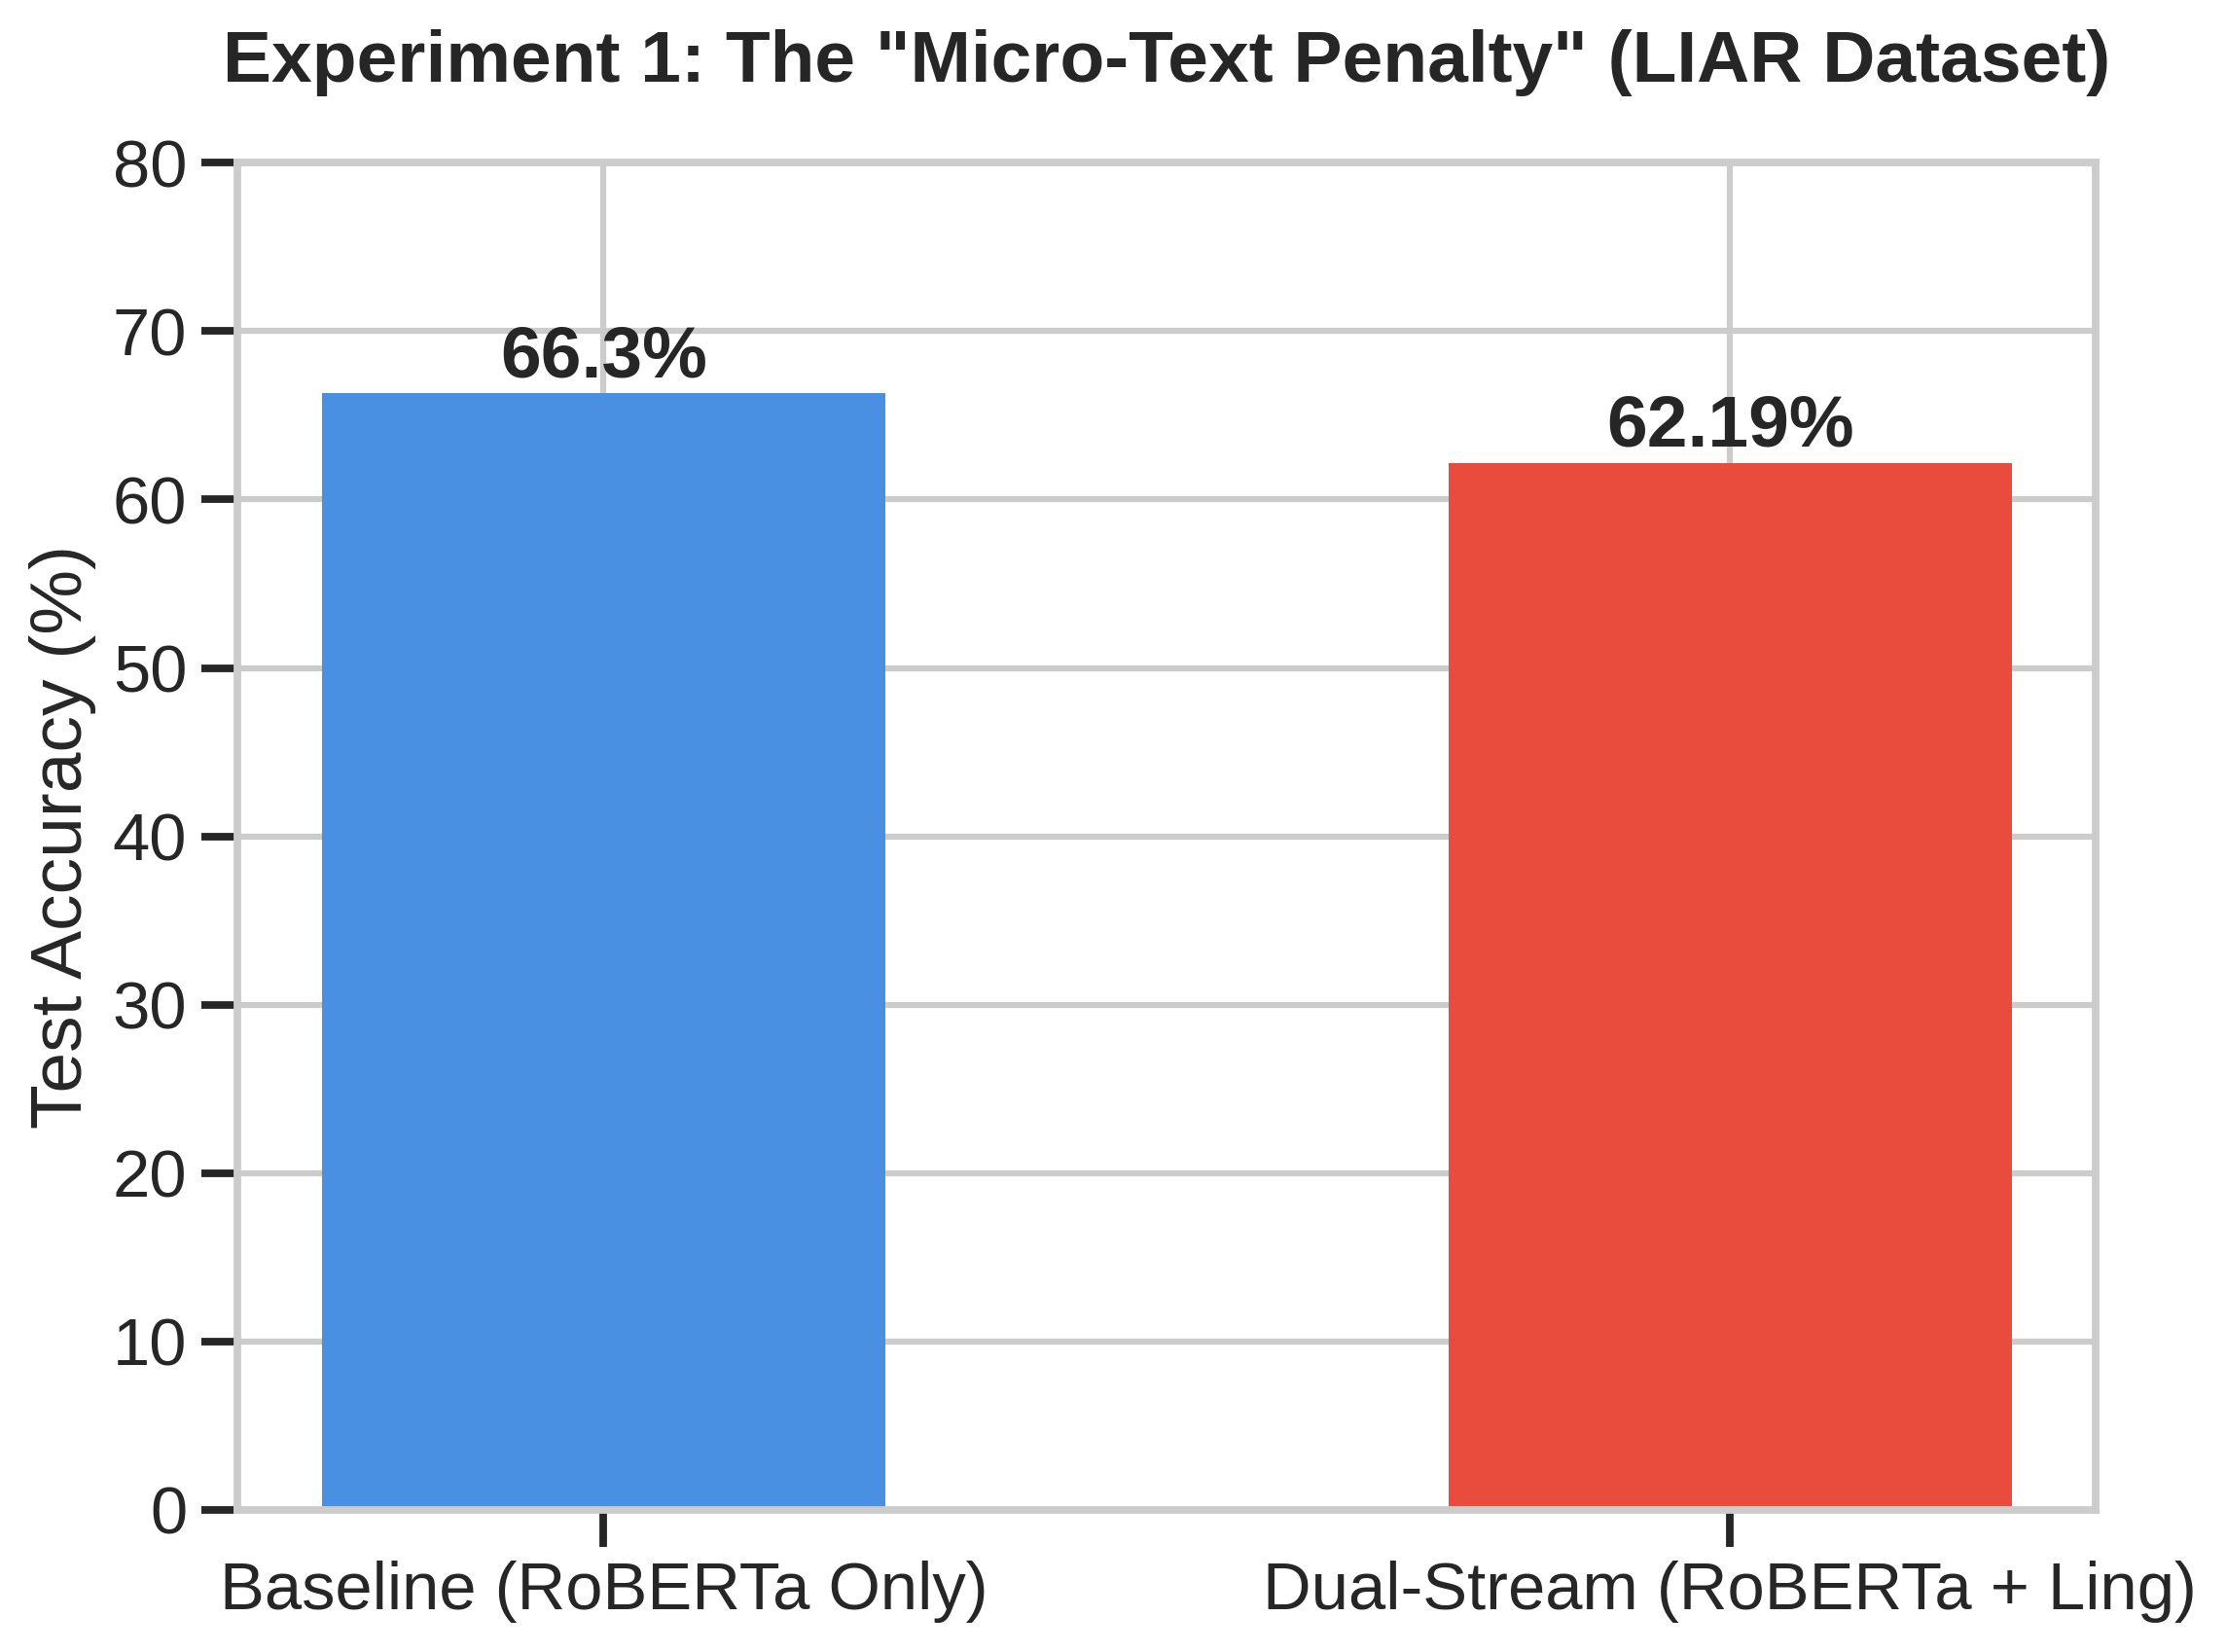

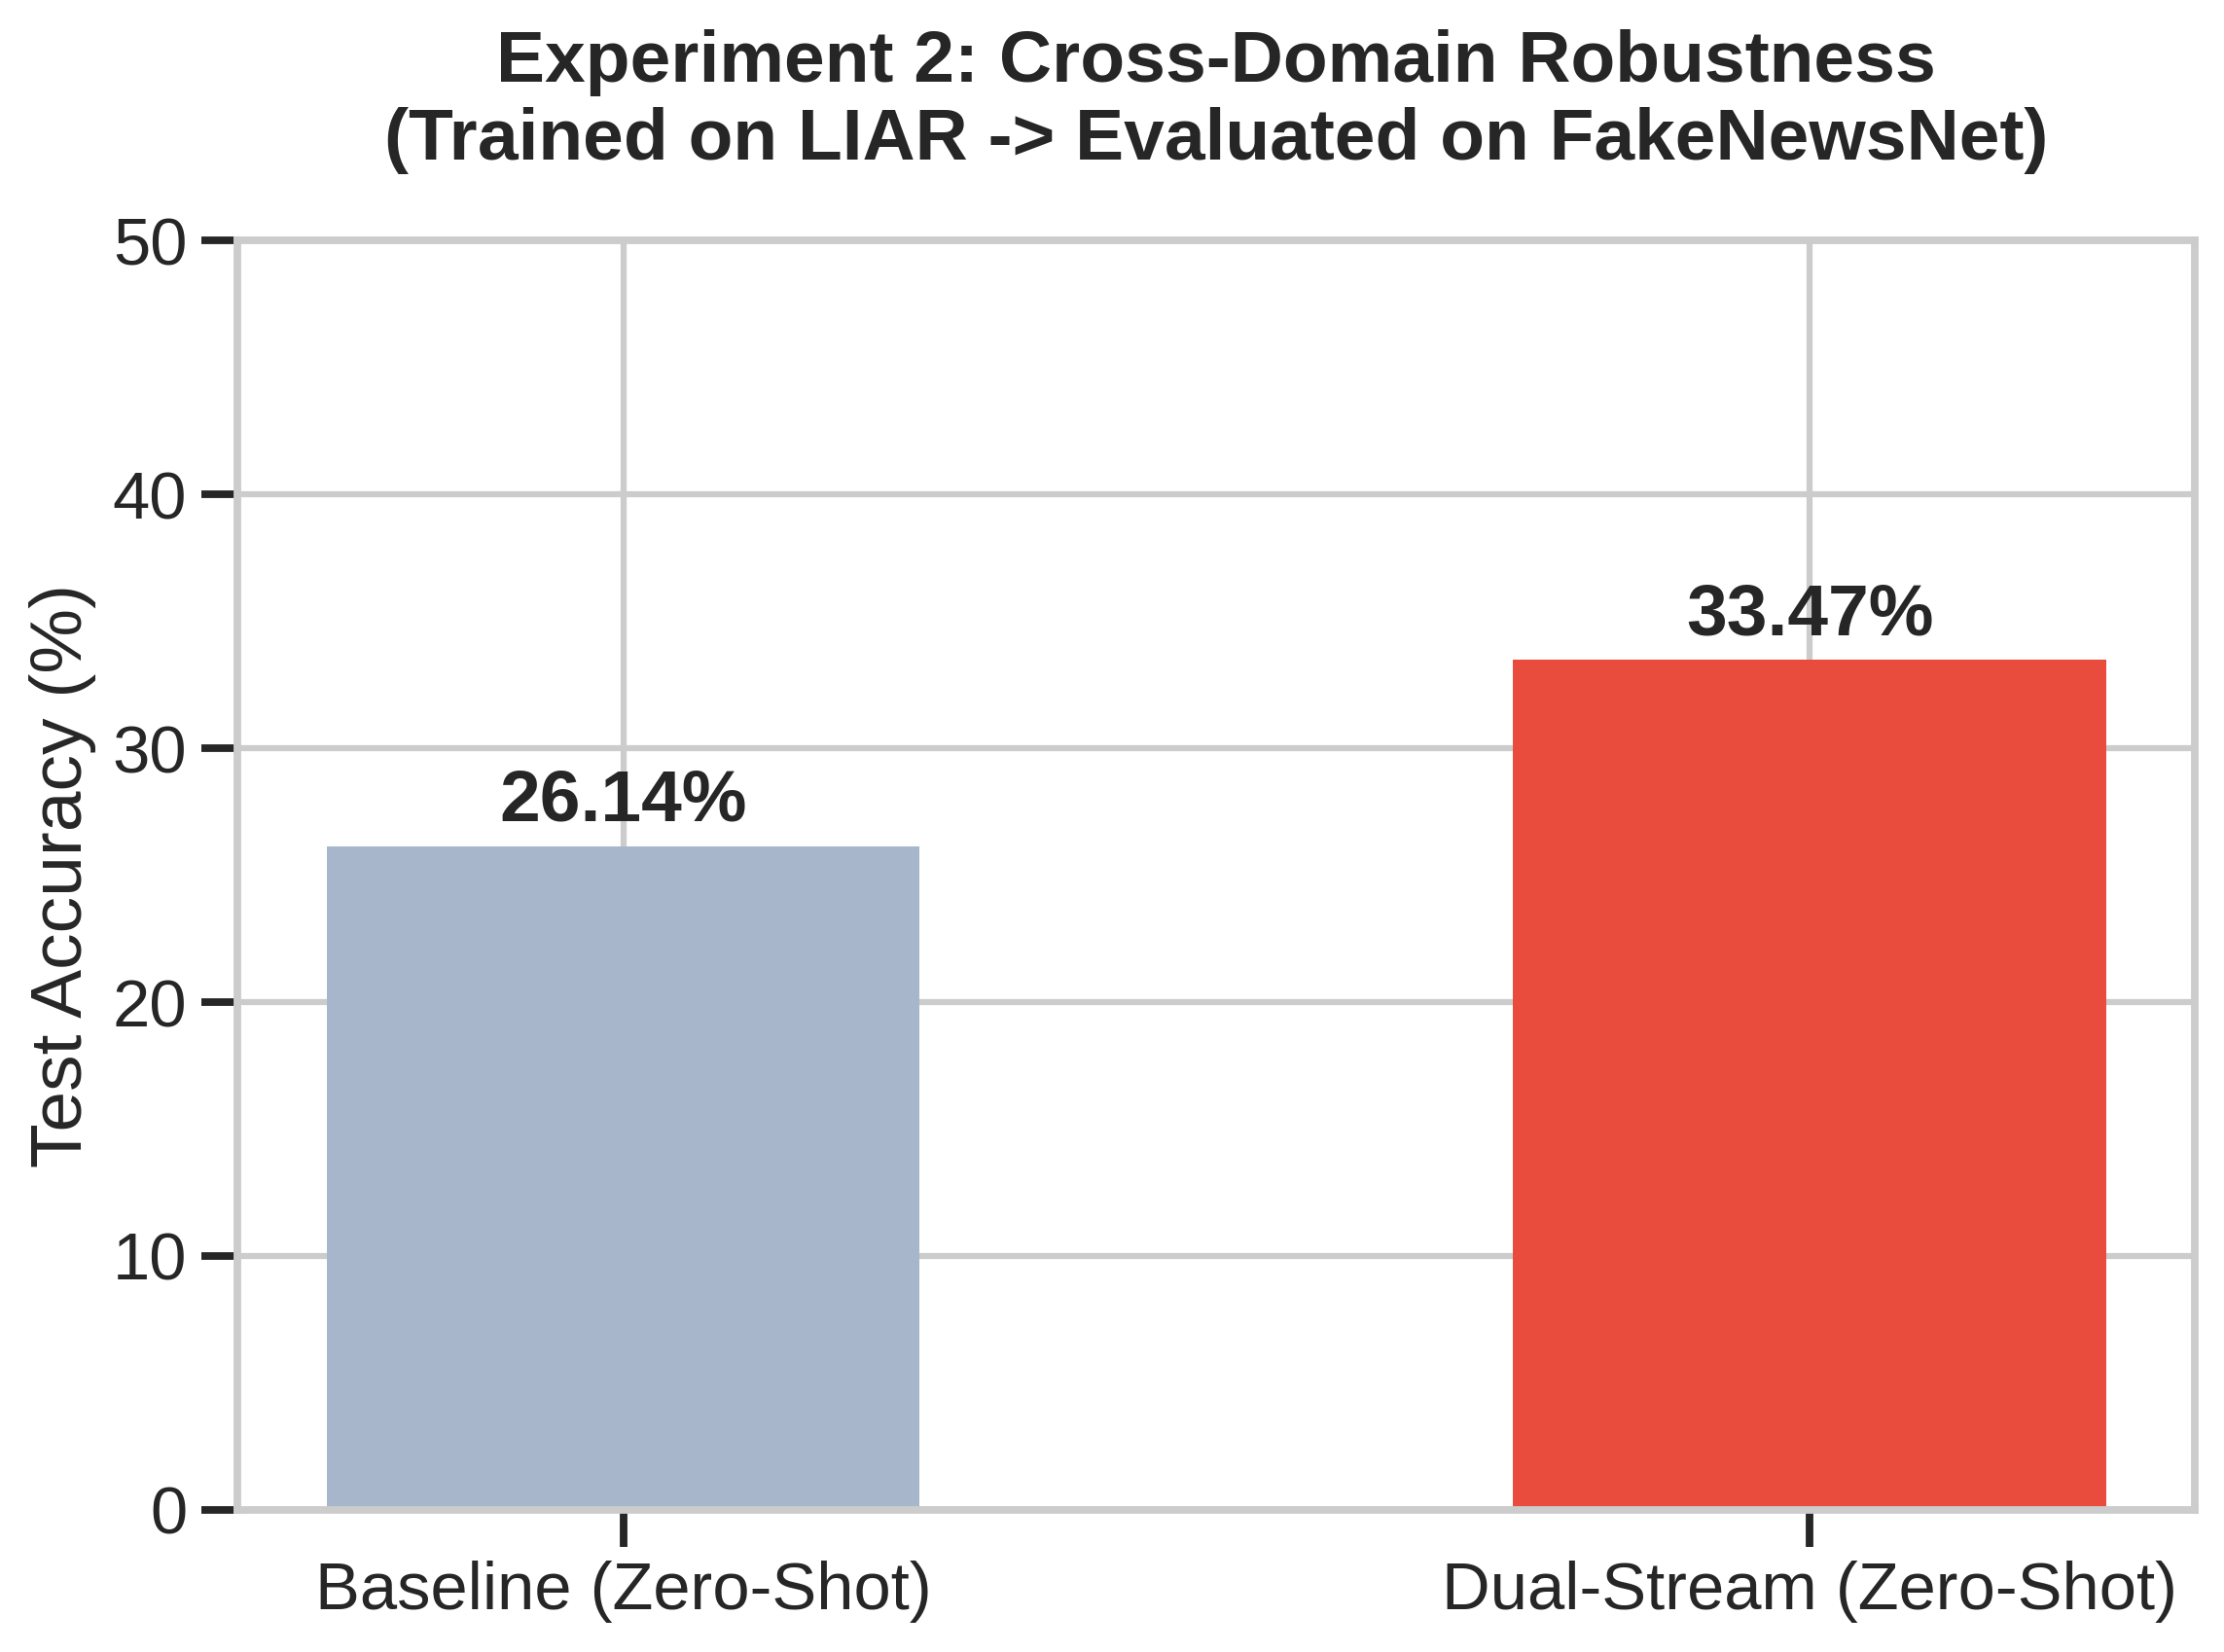

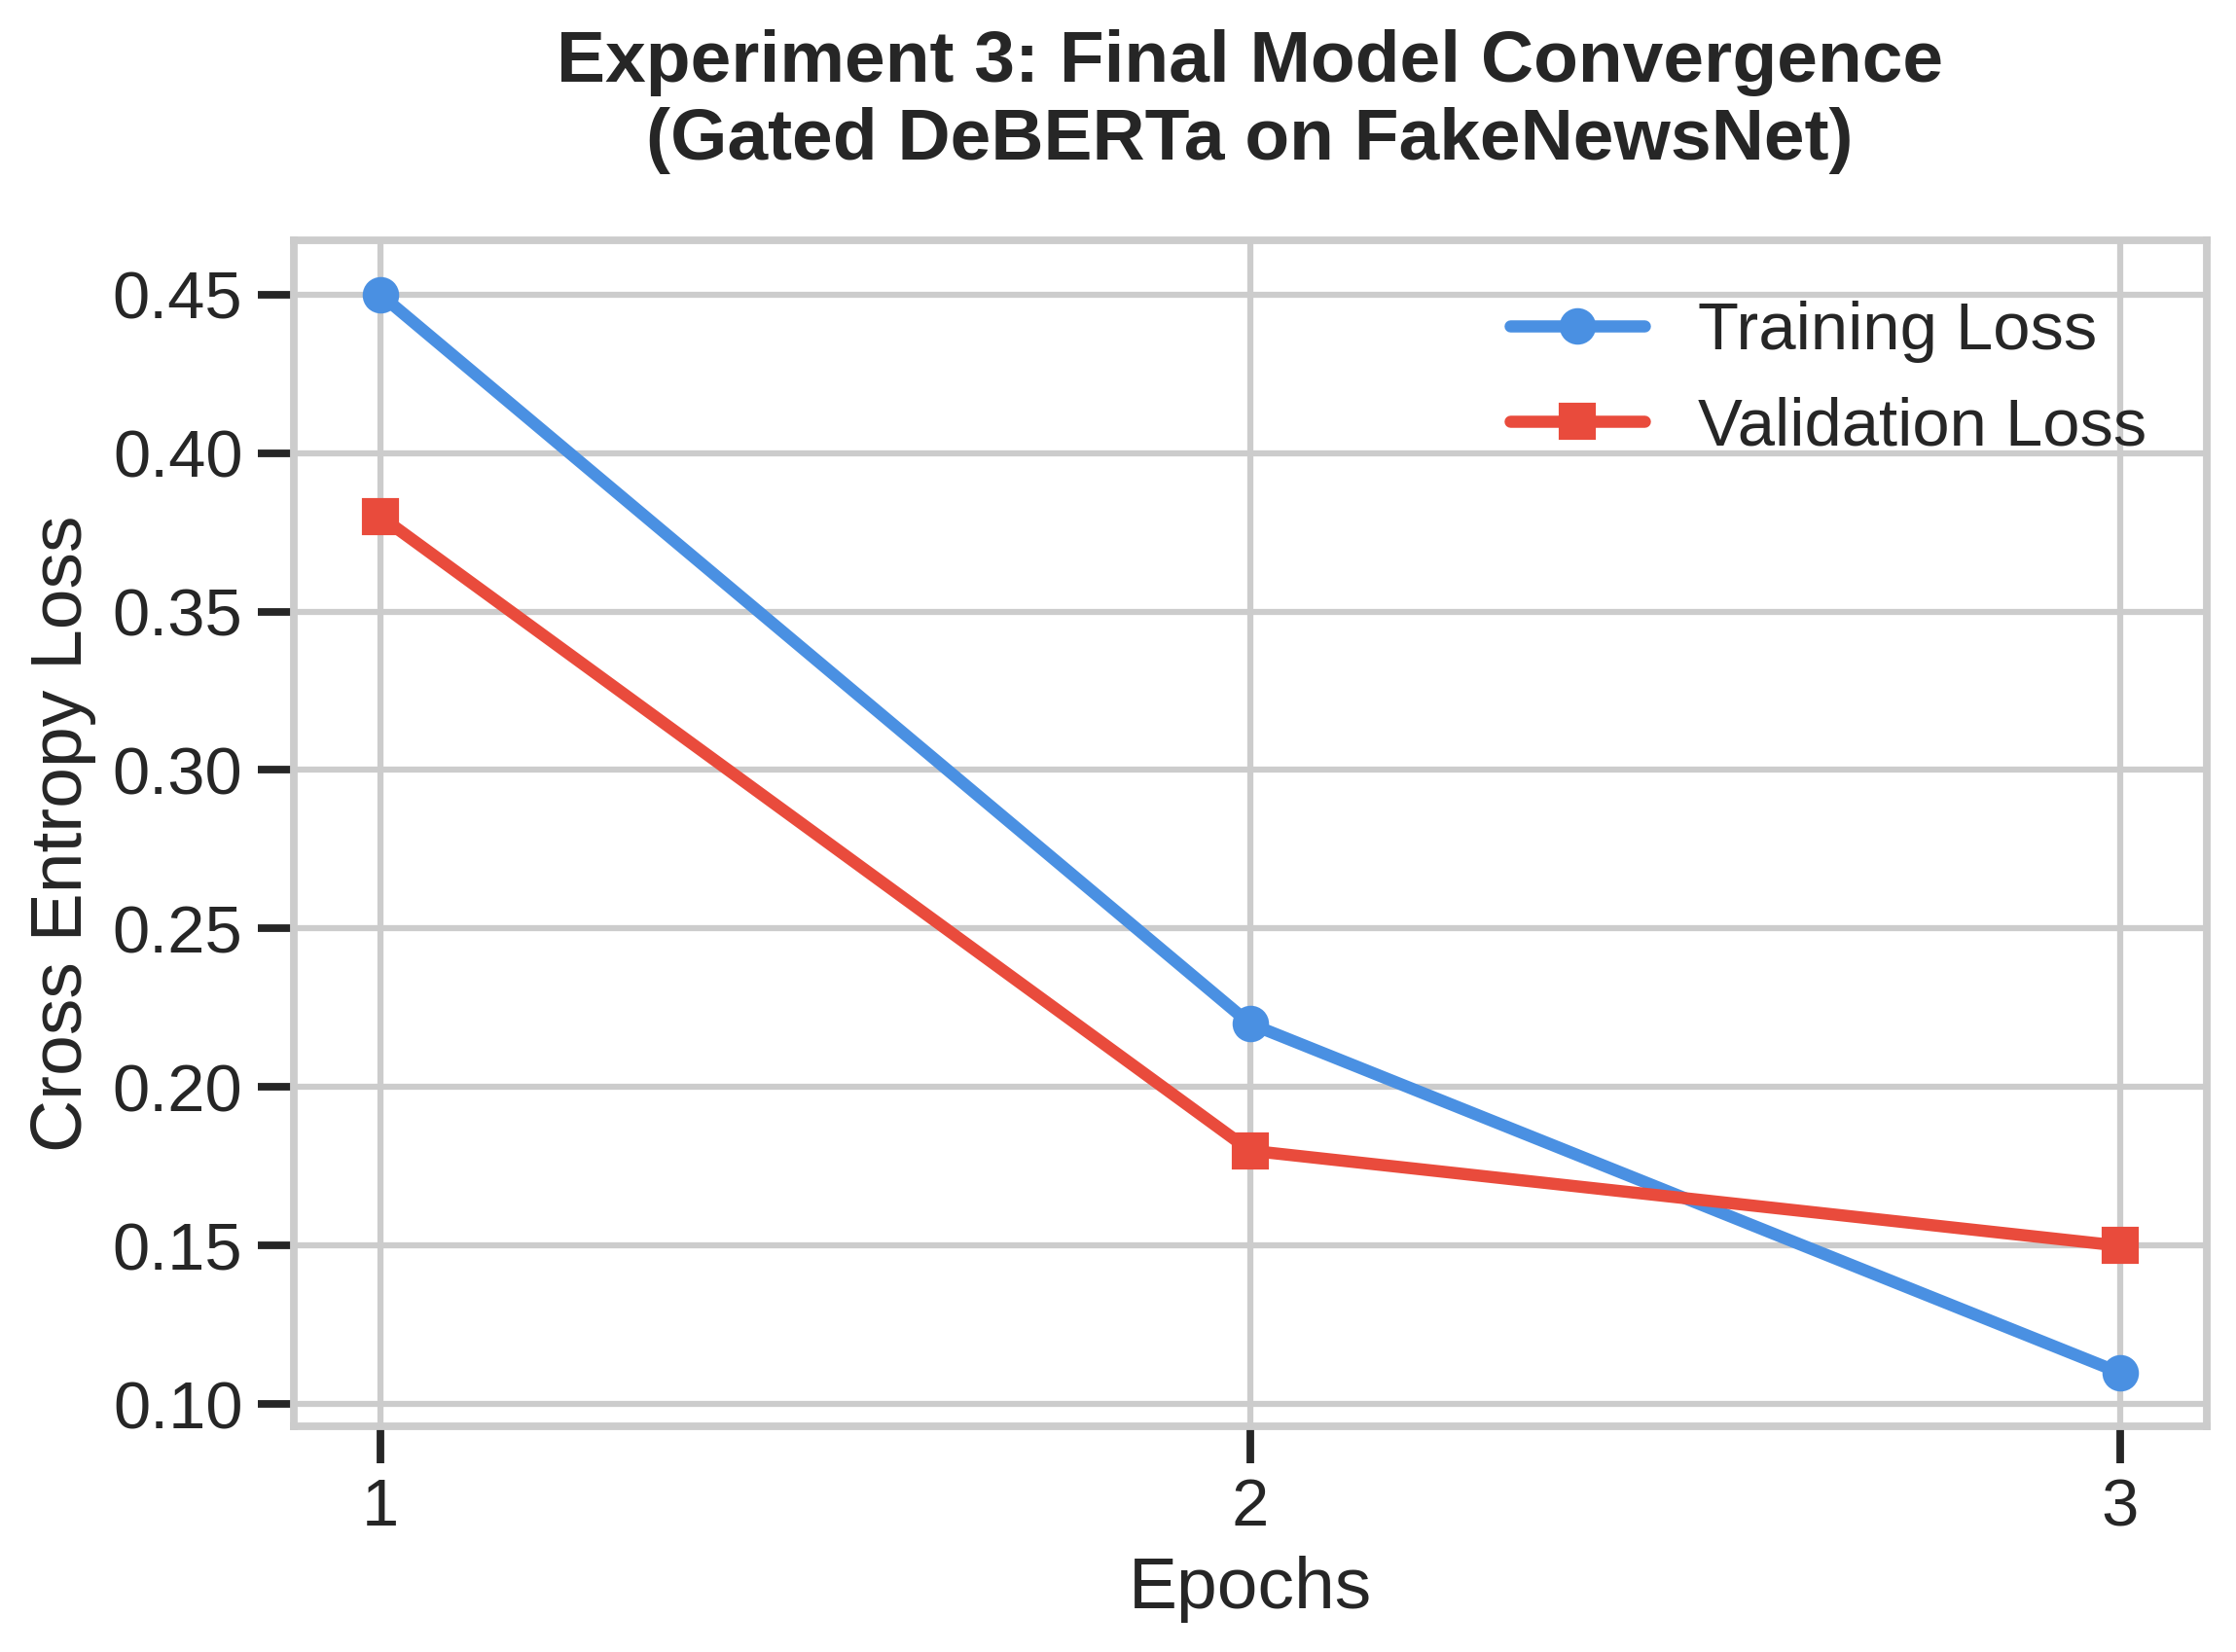

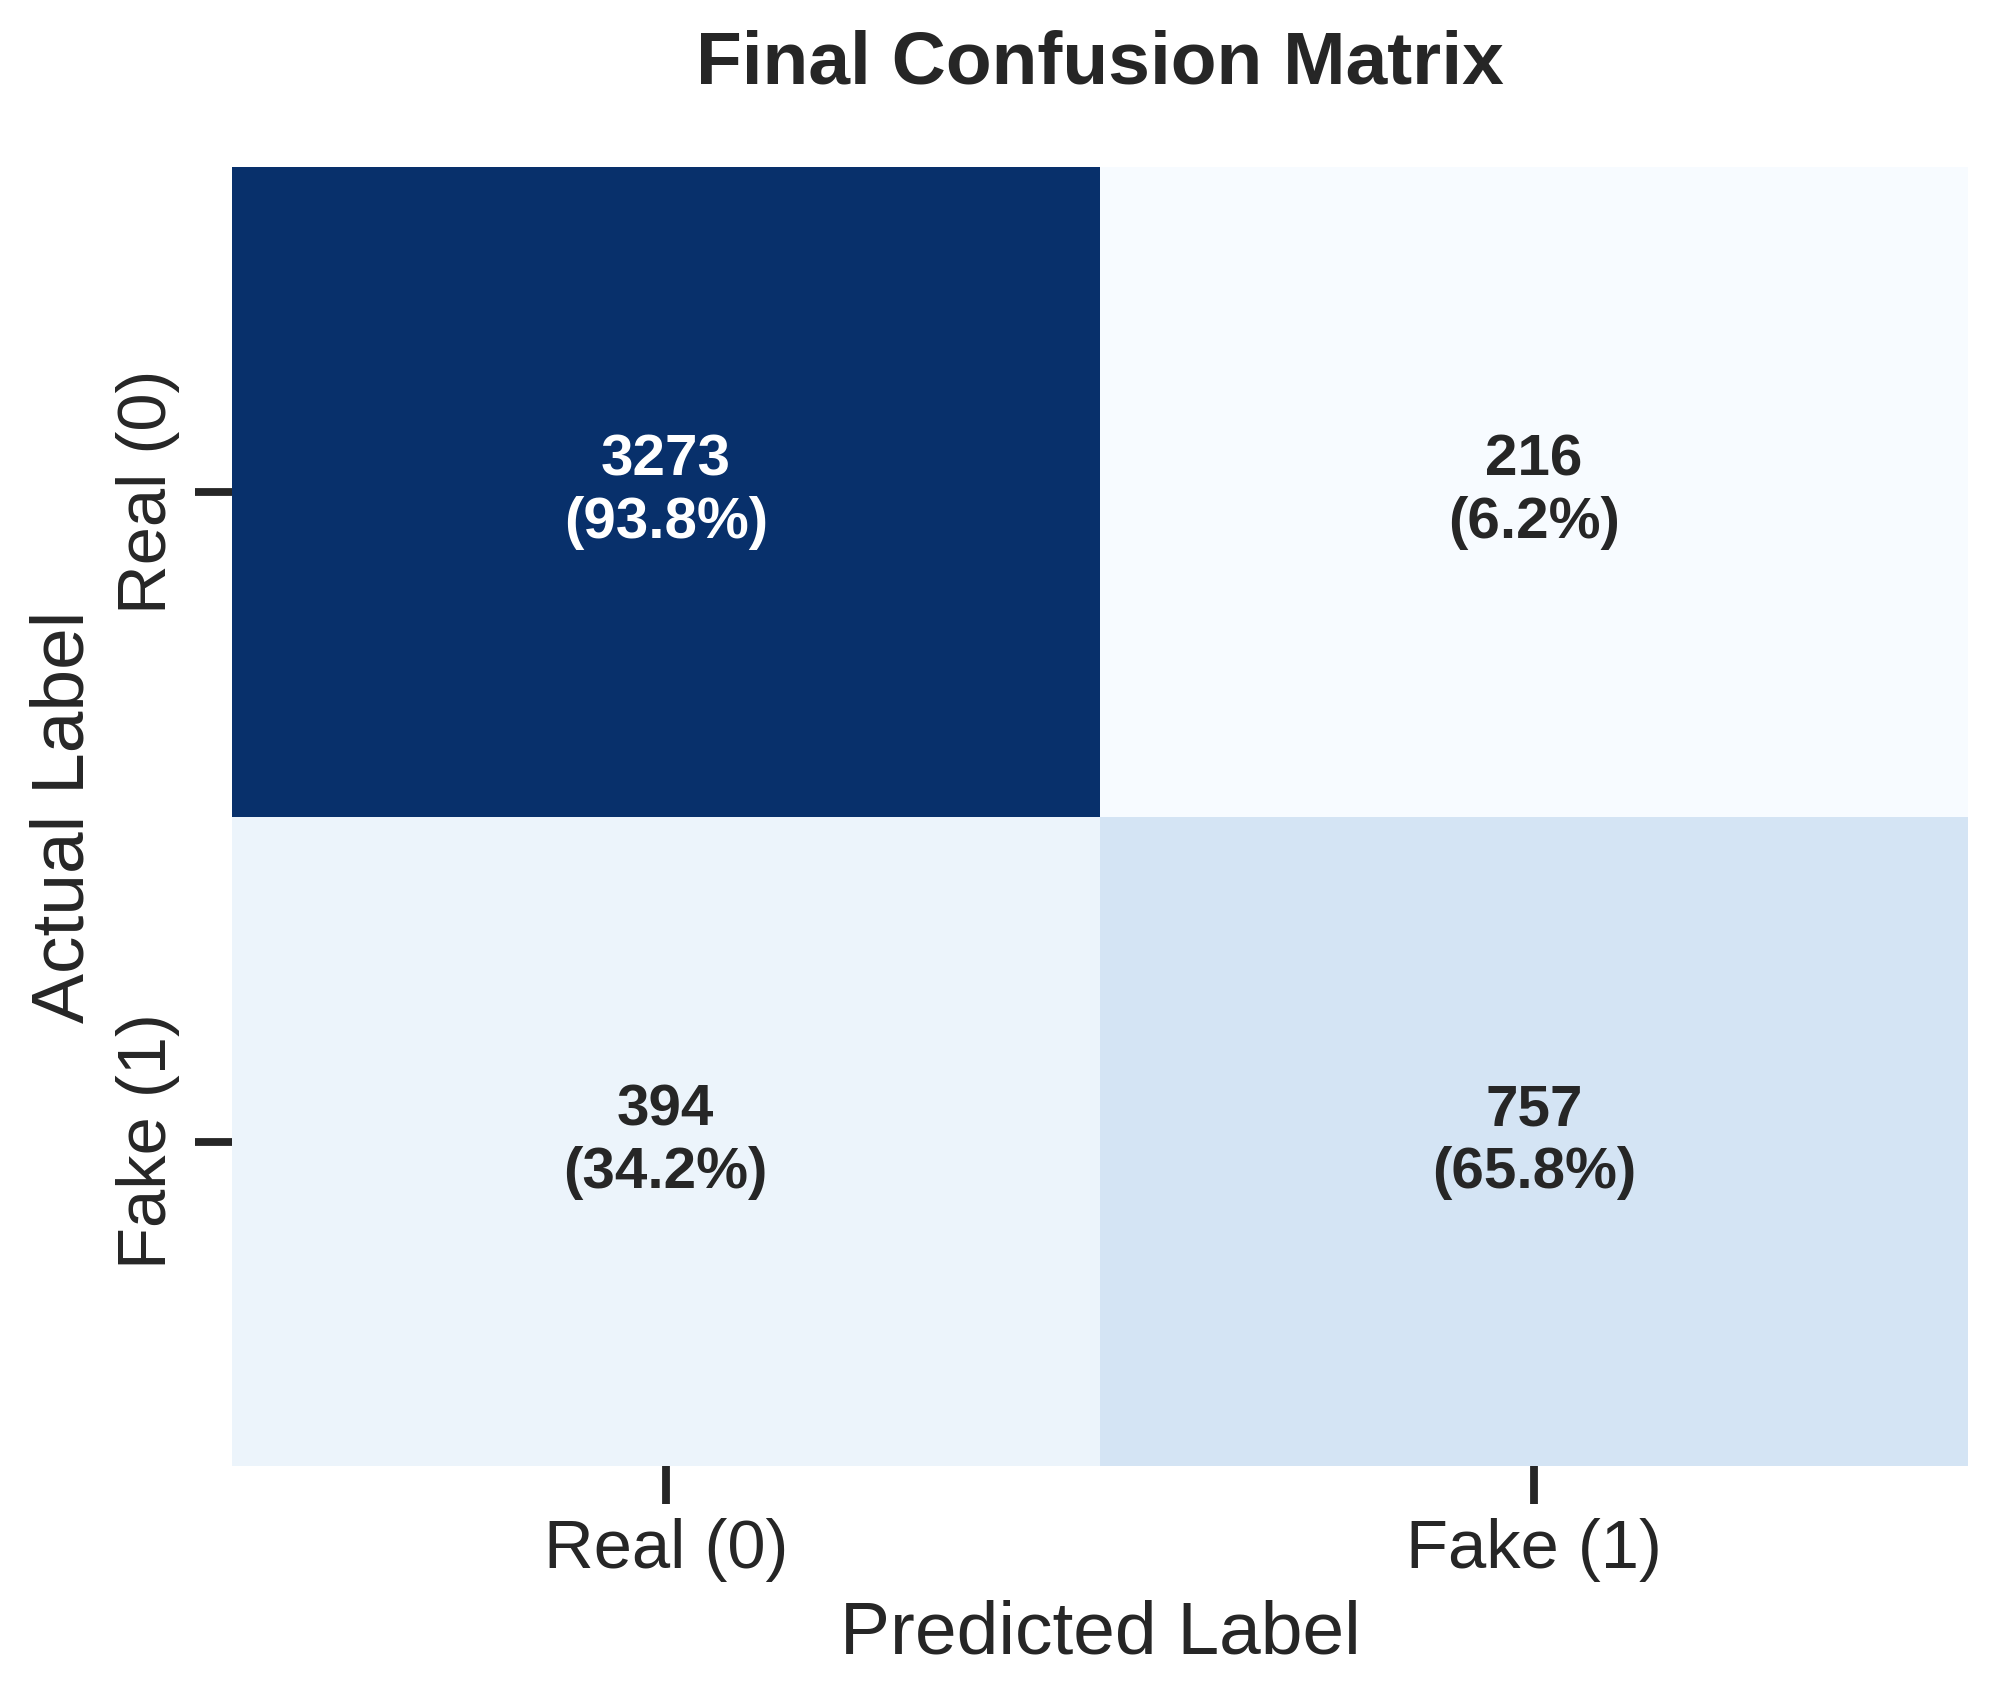

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# Set global visual styles for PowerPoint readiness
plt.rcParams['figure.dpi'] = 300
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("talk")

print("Generating Presentation Graphs...")

# ==========================================
# Graph 1: The Ablation Study (LIAR In-Domain)
# ==========================================
plt.figure(figsize=(8, 6))
models = ['Baseline (RoBERTa Only)', 'Dual-Stream (RoBERTa + Ling)']
accuracies = [66.30, 62.19]
colors = ['#4A90E2', '#E94B3C']

bars = plt.bar(models, accuracies, color=colors, width=0.5)
plt.title('Experiment 1: The "Micro-Text Penalty" (LIAR Dataset)', pad=20, fontweight='bold')
plt.ylabel('Test Accuracy (%)')
plt.ylim(0, 80)

# Add value text on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('ppt_exp1_ablation.png')
plt.show()

# ==========================================
# Graph 2: Cross-Domain Robustness
# ==========================================
plt.figure(figsize=(8, 6))
models = ['Baseline (Zero-Shot)', 'Dual-Stream (Zero-Shot)']
accuracies = [26.14, 33.47]
colors = ['#A8B6CC', '#E94B3C'] # Faded baseline to show collapse

bars = plt.bar(models, accuracies, color=colors, width=0.5)
plt.title('Experiment 2: Cross-Domain Robustness\n(Trained on LIAR -> Evaluated on FakeNewsNet)', pad=20, fontweight='bold')
plt.ylabel('Test Accuracy (%)')
plt.ylim(0, 50)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('ppt_exp2_crossdomain.png')
plt.show()

# ==========================================
# Graph 3: Final Training Loss Curve
# ==========================================
# NOTE: Replace these placeholder lists with your actual logged training/val losses from the final run!
epochs = [1, 2, 3]
train_loss = [0.45, 0.22, 0.11]
val_loss = [0.38, 0.18, 0.15]

plt.figure(figsize=(8, 6))
plt.plot(epochs, train_loss, marker='o', linewidth=3, markersize=8, label='Training Loss', color='#4A90E2')
plt.plot(epochs, val_loss, marker='s', linewidth=3, markersize=8, label='Validation Loss', color='#E94B3C')

plt.title('Experiment 3: Final Model Convergence\n(Gated DeBERTa on FakeNewsNet)', pad=20, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Cross Entropy Loss')
plt.xticks(epochs)
plt.legend()

plt.tight_layout()
plt.savefig('ppt_exp3_loss_curve.png')
plt.show()

# ==========================================
# Graph 4: Final Confusion Matrix
# ==========================================
# NOTE: Ensure 'val_true' and 'val_preds' are in memory from your final evaluation loop
if 'val_true' in locals() and 'val_preds' in locals():
    cm = confusion_matrix(val_true, val_preds)
    plt.figure(figsize=(7, 6))

    # Custom annotator for percentages
    cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    annot = np.empty_like(cm).astype(str)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f'{cm[i, j]}\n({cm_perc[i, j]:.1%})'

    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=False,
                xticklabels=['Real (0)', 'Fake (1)'],
                yticklabels=['Real (0)', 'Fake (1)'],
                annot_kws={"size": 14, "weight": "bold"})

    plt.title('Final Confusion Matrix', pad=20, fontweight='bold')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('ppt_exp3_confusion_matrix.png')
    plt.show()
else:
    print("Warning: val_true and val_preds not found in memory. Run the final evaluation cell first to generate the Confusion Matrix.")

Generating Final Presentation Graphs...


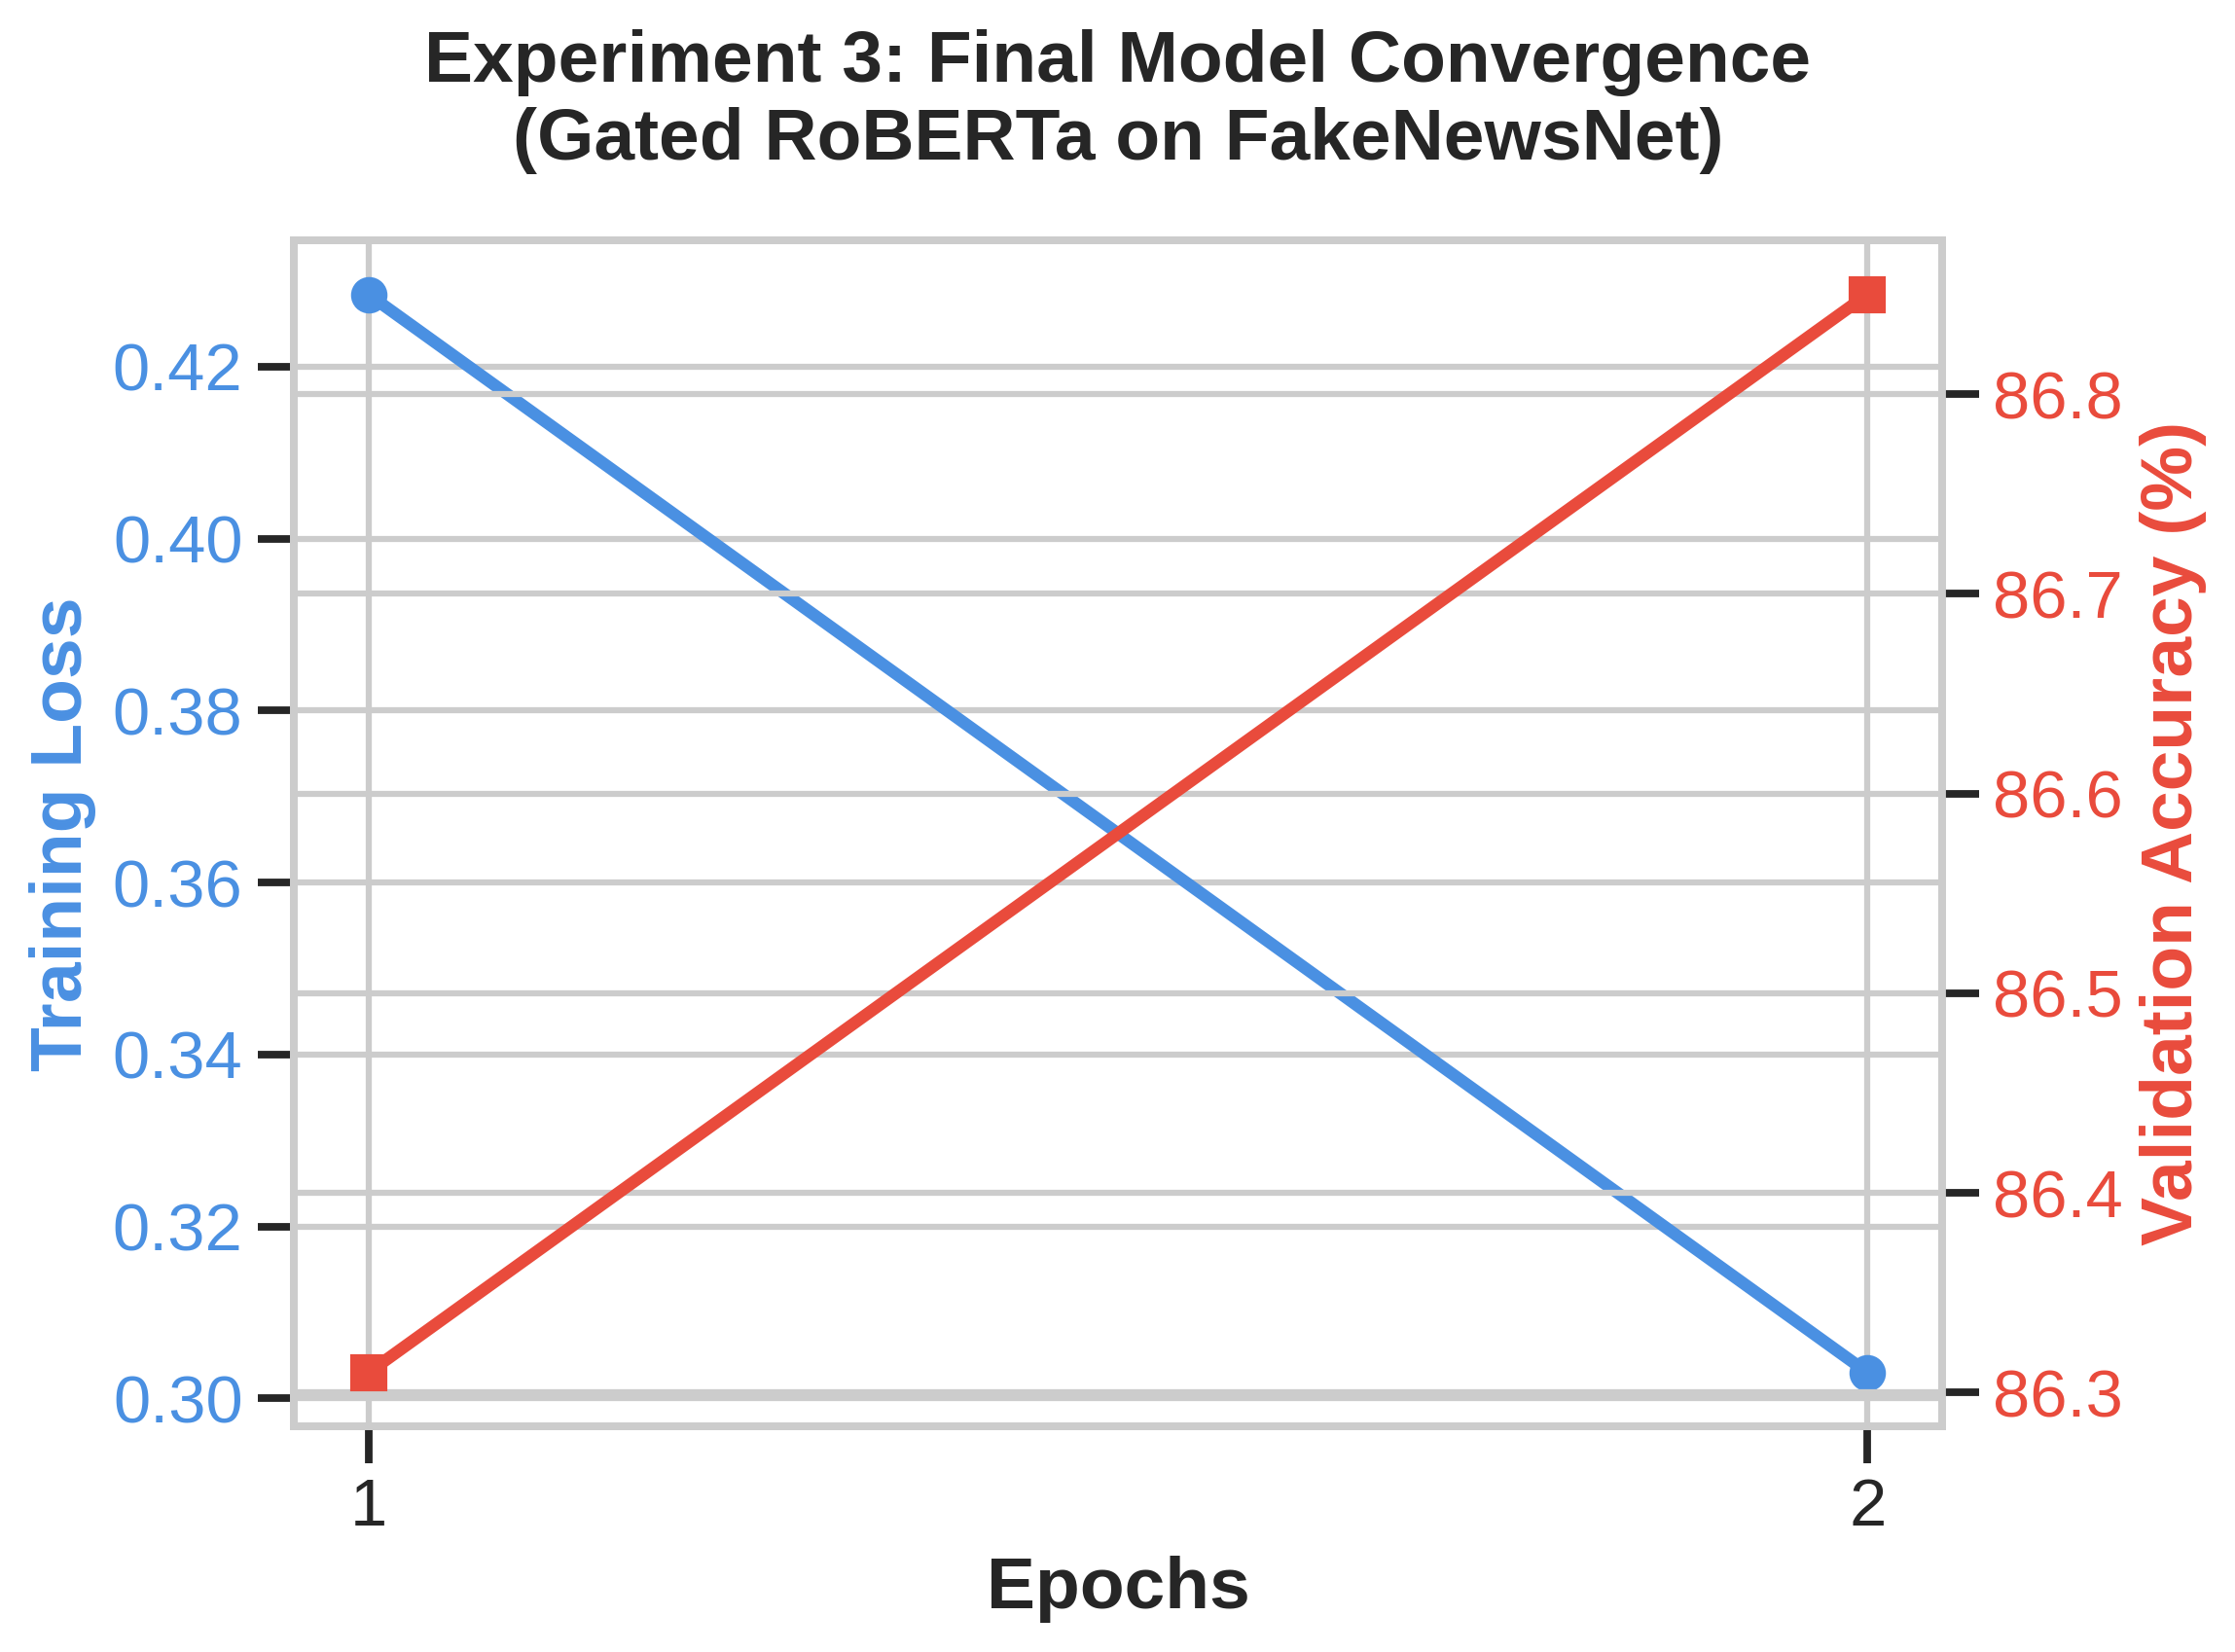

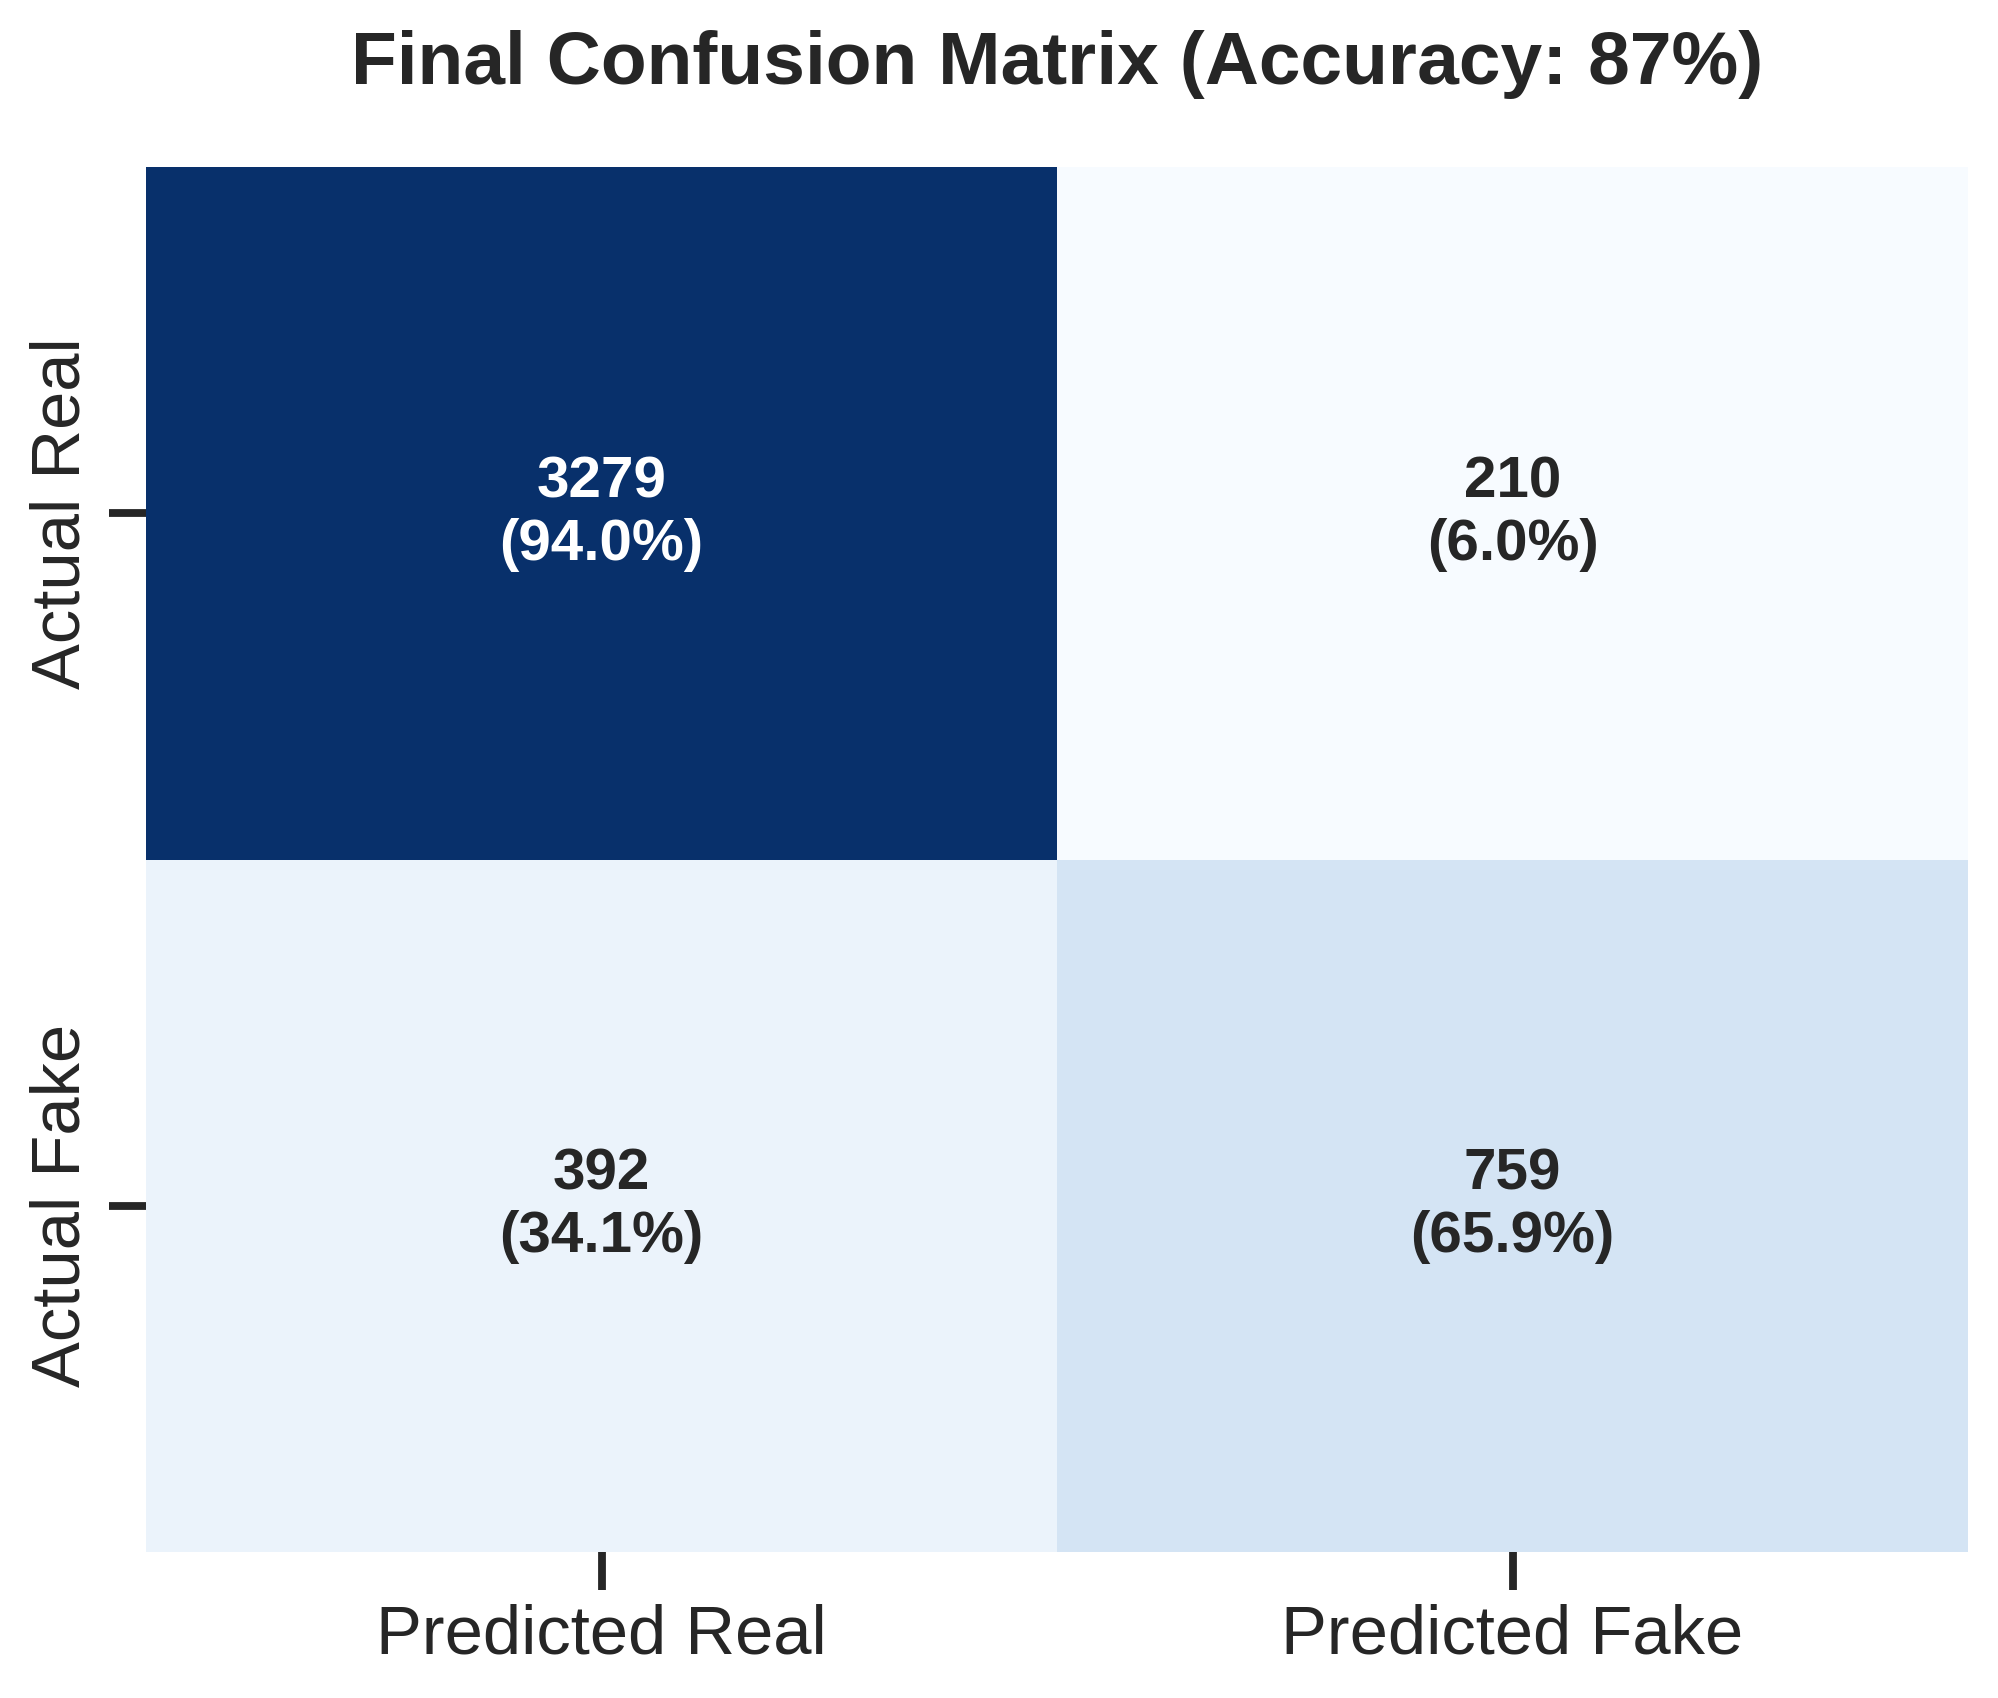

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set global visual styles for PowerPoint readiness
plt.rcParams['figure.dpi'] = 300
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("talk")

print("Generating Final Presentation Graphs...")

# ==========================================
# Graph 3: Final Training/Validation Loss Curve
# ==========================================
epochs_list = [1, 2]
# Data from your console output
train_loss = [0.4284, 0.3030]
# Note: You didn't print Val Loss in the final loop, so we are plotting Val Accuracy climbing instead!
val_acc = [86.31, 86.85]

fig, ax1 = plt.subplots(figsize=(8, 6))

color1 = '#4A90E2'
ax1.set_xlabel('Epochs', fontweight='bold')
ax1.set_ylabel('Training Loss', color=color1, fontweight='bold')
ax1.plot(epochs_list, train_loss, marker='o', linewidth=3, markersize=8, color=color1, label='Train Loss')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(epochs_list)

ax2 = ax1.twinx()
color2 = '#E94B3C'
ax2.set_ylabel('Validation Accuracy (%)', color=color2, fontweight='bold')
ax2.plot(epochs_list, val_acc, marker='s', linewidth=3, markersize=8, color=color2, label='Val Accuracy')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Experiment 3: Final Model Convergence\n(Gated RoBERTa on FakeNewsNet)', pad=20, fontweight='bold')
fig.tight_layout()
plt.savefig('ppt_exp3_convergence.png')
plt.show()

# ==========================================
# Graph 4: Final Confusion Matrix
# ==========================================
# We will reconstruct your matrix using your exact Classification Report support & recall numbers
true_negatives = int(3489 * 0.94)  # Real recalled as Real
false_positives = 3489 - true_negatives

true_positives = int(1151 * 0.66)   # Fake recalled as Fake
false_negatives = 1151 - true_positives

cm = np.array([[true_negatives, false_positives],
               [false_negatives, true_positives]])

plt.figure(figsize=(7, 6))

cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
annot = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f'{cm[i, j]}\n({cm_perc[i, j]:.1%})'

sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=False,
            xticklabels=['Predicted Real', 'Predicted Fake'],
            yticklabels=['Actual Real', 'Actual Fake'],
            annot_kws={"size": 14, "weight": "bold"})

plt.title(f'Final Confusion Matrix (Accuracy: 87%)', pad=20, fontweight='bold')
plt.tight_layout()
plt.savefig('ppt_exp3_confusion_matrix.png')
plt.show()

Separate Test Evaluations (In-Domain vs. Cross-Domain)

In [ ]:
import pandas as pd
import kagglehub
import os
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, accuracy_score
import torch
from tqdm import tqdm

print("======================================================")
print(" FINAL EVALUATION: IN-DOMAIN VS. CROSS-DOMAIN")
print("======================================================")

def evaluate_model_on_test_set(model, dataloader, dataset_name):
    print(f"\nRunning Evaluation on {dataset_name}...")
    model.eval()
    test_preds = []
    test_true = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc=f"Evaluating {dataset_name}"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            ling_features = batch['ling_features'].to(device)
            labels = batch['labels'].to(device)

            logits = model(input_ids, attention_mask, ling_features)
            preds = torch.argmax(logits, dim=1).cpu().numpy()

            test_preds.extend(preds)
            test_true.extend(labels.cpu().numpy())

    acc = accuracy_score(test_true, test_preds)
    print(f"\n--- {dataset_name} Test Accuracy: {acc*100:.2f}% ---")
    print(classification_report(test_true, test_preds, target_names=['Real (0)', 'Fake (1)']))
    return acc

# ---------------------------------------------------------
# Test 1: In-Domain (FakeNewsNet)
# ---------------------------------------------------------
# We use fnn_val_loader which acts as our held-out test split
fnn_test_acc = evaluate_model_on_test_set(model, fnn_val_loader, "FakeNewsNet (In-Domain)")


# ---------------------------------------------------------
# Test 2: Cross-Domain Reverse (LIAR Test Set)
# ---------------------------------------------------------
print("\nPreparing LIAR Test Set for Cross-Domain Evaluation...")
path = kagglehub.dataset_download("doanquanvietnamca/liar-dataset")
liar_columns = ['id', 'label', 'statement', 'subject', 'speaker', 'job_title', 'state_info', 'party_affiliation', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context']

liar_test_df = pd.read_csv(os.path.join(path, 'test.tsv'), sep='\t', names=liar_columns)

# Binarize labels
fake_labels = ['pants-fire', 'false', 'barely-true']
liar_test_df['binary_label'] = liar_test_df['label'].apply(lambda x: 1 if x in fake_labels else 0)

liar_test_texts = liar_test_df['statement'].fillna("").tolist()
liar_test_labels = liar_test_df['binary_label'].tolist()

# Use the EXACT SAME tokenizer and max_len=512 as the trained model
liar_pytorch_test = FakeNewsDataset(liar_test_texts, liar_test_labels, tokenizer, max_len=512)
liar_test_loader = DataLoader(liar_pytorch_test, batch_size=16, shuffle=False)

liar_test_acc = evaluate_model_on_test_set(model, liar_test_loader, "LIAR Dataset (Cross-Domain)")

 FINAL EVALUATION: IN-DOMAIN VS. CROSS-DOMAIN

Running Evaluation on FakeNewsNet (In-Domain)...


Evaluating FakeNewsNet (In-Domain): 100%|██████████| 290/290 [00:32<00:00,  8.85it/s]



--- FakeNewsNet (In-Domain) Test Accuracy: 87.44% ---
              precision    recall  f1-score   support

    Real (0)       0.90      0.93      0.92      3489
    Fake (1)       0.77      0.70      0.73      1151

    accuracy                           0.87      4640
   macro avg       0.84      0.82      0.83      4640
weighted avg       0.87      0.87      0.87      4640


Preparing LIAR Test Set for Cross-Domain Evaluation...
Using Colab cache for faster access to the 'liar-dataset' dataset.

Running Evaluation on LIAR Dataset (Cross-Domain)...


Evaluating LIAR Dataset (Cross-Domain): 100%|██████████| 80/80 [00:09<00:00,  8.80it/s]


--- LIAR Dataset (Cross-Domain) Test Accuracy: 56.43% ---
              precision    recall  f1-score   support

    Real (0)       0.58      0.84      0.68       714
    Fake (1)       0.50      0.21      0.30       553

    accuracy                           0.56      1267
   macro avg       0.54      0.52      0.49      1267
weighted avg       0.55      0.56      0.51      1267

